# LeJEPA for Label-Efficient, Explainable Defect Detection — corrected protocol (version 02)

This notebook is `01_architecture_original.ipynb` with a **corrected evaluation
protocol** and a **controlled set of small experiments**. The architecture
(block-masked LeJEPA, SIGReg, latent-error acquisition, Random Forest + SHAP on
raw sensors, expert review) is unchanged. What changed is *how the data is
partitioned, how preprocessing is fitted, how checkpoints are selected, and how
every configuration is compared*.

| # | Change | Where | Why |
| --- | --- | --- | --- |
| 1 | Restrict to machine **S14** (`MAIN_EQUIPMENT`), keep the original CSV row numbers as metadata | STEP 0, 1 | S14 holds 5230 of 5232 records and all 60 defects; the two foreign records had no defects and no business in the split |
| 2 | **Group-aware** pool / tuning / test split on (`EQUIP_CD`, `TimeStamp`) with `GroupShuffleSplit` | STEP 1 | Left- and right-hand parts of one shot are *identical sensor rows*; a random split leaks the test set into the pool |
| 3 | Scaler, dead-sensor status, correlation blocks, effective rank and the PCA baseline are fitted on the **pool only**; exactly constant columns are always removed | STEP 1 | No information from tuning or test records reaches preprocessing; `Barrel_Temperature_7` is constant on S14 |
| 4 | Checkpoint selection uses the **same 5 validation mask draws and the same SIGReg directions** at every epoch (`N_VAL_MASK_DRAWS`) | STEP 3 | The validation curve becomes comparable across epochs and runs |
| 5 | Scoring, querying, random and PCA baselines all use the **pool**; classifiers are judged on the **tuning** partition during development | STEP 4, 6 | Same information for every strategy; the test set stays untouched until the end |
| 6 | One reference configuration, saved before anything else is changed | STEP 6 | All experiments are compared against this corrected baseline |
| 7–12 | Experiments A–F, one setting at a time, five seeds each | STEP 9 | Mask draws, dead sensors, part identity, latent width, λ, encoder width |
| 13 | One results table with fixed columns, discovery and classifier metrics kept apart | STEP 9 | Decided *before* selection: **defect discovery within the budget is the primary criterion**, downstream AP is secondary |
| 14 | Expert step reduced to a **limited qualitative review**: six held-out cases, the final classifier's SHAP explanation only (top three variables), recorded outcome shown, two questions per case | STEP 7 | A supporting analysis with a modest workload; it reviews the downstream classifier's explanations and makes no claim of validated actionability or causality |

Labels `y` are read only for queried records and for evaluation. Pre-training never
sees them. Every random stream is seeded; experiments re-create networks and pass
every setting **explicitly** so that no function silently keeps a default from an
earlier configuration.

## STEP 0 — Setup and configuration

In [1]:
# =============================================================================
# STEP 0: Imports, reproducibility, and ONE place for every knob in the pipeline
# =============================================================================
import os
import time
import json
import textwrap
import warnings

warnings.filterwarnings('ignore', message='IProgress not found')
warnings.filterwarnings('ignore', category=FutureWarning, message='The NumPy global RNG')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score

T_START = time.time()

# ---------------- reproducibility & CPU budget --------------------------------
SEED = 42
N_THREADS = 8
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_num_threads(N_THREADS)

# ---------------- data (STEP 1) ----------------------------------------------
DATA_PATH = '../data/labeled_data_preprocessed.csv'
MAIN_EQUIPMENT = 'S14'                    # NEW: the study is restricted to this machine
METADATA_COLUMNS = ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
                    'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'Reason', 'PassOrFail']
LABEL_COLUMN = 'PassOrFail'               # 1 = defect, 0 = pass
REASON_COLUMN = 'Reason'                  # defect type; reporting only
REASON_LABELS = {'가스': 'gas', '미성형': 'short_shot', '초기허용불량': 'startup'}
DEFECT_TYPES = ['gas', 'short_shot', 'startup']
DEAD_SENSOR_MODAL_SHARE = 0.95            # modal value covering > this share = near-constant
DROP_DEAD_SENSORS = True                  # baseline: drop near-constant sensors (constant ones are ALWAYS dropped)

# ---------------- partitions (STEP 1) ----------------------------------------
TEST_GROUP_FRAC = 0.25                    # NEW: share of (machine, timestamp) groups held out for the final test
TUNING_GROUP_FRAC = 0.25                  # NEW: share of the remaining groups used to compare configurations
SPLIT_SEED_TEST, SPLIT_SEED_TUNING = 42, 43

# ---------------- correlated sensor blocks (STEP 1) --------------------------
BLOCK_DISTANCE_CUT = 0.3                  # |corr| > 0.7 -> same block

# ---------------- model (STEP 2) ---------------------------------------------
LATENT_DIM = 8
ENCODER_HIDDEN = (64, 32)
PREDICTOR_HIDDEN = 32
KEEP_PROB = 0.5                           # the exact scorer assumes 0.5
SIGREG_N_PROJ = 64
SIGREG_T_MAX, SIGREG_N_T = 3.0, 17

# ---------------- pre-training (STEP 3) --------------------------------------
EPOCHS = 150
BATCH_SIZE = 256
LEARNING_RATE = 3e-3
WEIGHT_DECAY = 1e-4
LAMBDA_SIGREG = 1.0
VAL_FRAC = 0.15                           # label-free, group-aware held-out share of the pool
PATIENCE = 25
N_VAL_MASK_DRAWS = 5                      # NEW: fixed validation mask draws per epoch
LOG_EVERY = 25

# ---------------- active learning (STEP 4) -----------------------------------
LABELING_BUDGET = 300                     # 300 labelled part records
N_MASK_DRAWS = 50
SCORING_MODE = 'mc'                       # 'mc' or 'exact'
N_RANDOM_BASELINE_DRAWS = 10
RF_N_ESTIMATORS = 300
RF_N_JOBS = -1
RF_USE_PART_NAME = False                  # NEW: one-hot PART_NAME appended to the forest input only

# ---------------- multi-seed evaluation (STEP 6) -----------------------------
SEEDS = [0, 1, 2, 3, 4]

# ---------------- experiments (STEP 9) ---------------------------------------
RESULTS_DIR = 'results_v2'
RUN_EXPERIMENT_F = True                   # the optional wider encoder (5 more pre-training runs)

# ---------------- expert review (STEP 7) -------------------------------------
EXPERT_DIR = 'expert_review'
N_EXPERT_CASES = 6                        # three defective + three non-defective held-out parts
N_EXPERT_TOP_SENSORS = 3                  # process variables shown per explanation
SENSOR_UNITS = {}                         # VERIFIED units only, e.g. {'Max_Injection_Pressure': 'bar'};
                                          # a variable without an entry is shown without a unit
EXPERT_PACKET_SEED = 20260908

# ---------------- plotting ----------------------------------------------------
BLUE, ORANGE, GRAY, GREEN, RED = '#2a78d6', '#eb6834', '#898781', '#1baf7a', '#e34948'

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"torch {torch.__version__} | threads={torch.get_num_threads()} | seed={SEED} | equipment={MAIN_EQUIPMENT} "
      f"| scoring={SCORING_MODE}/{N_MASK_DRAWS} | budget={LABELING_BUDGET} | seeds={SEEDS}")

torch 2.14.0+cpu | threads=8 | seed=42 | equipment=S14 | scoring=mc/50 | budget=300 | seeds=[0, 1, 2, 3, 4]


## STEP 1 — Data, group-aware partitions, and pool-only preprocessing

Three protocol fixes live here. **(1)** The study is restricted to machine S14 and
the original CSV row numbers are kept as metadata. **(2)** The data is split into
pool / tuning / test **by group**, where a group is one (machine, timestamp) shot:
the left-hand and right-hand parts of a shot are the same sensor row, so a random
split would place copies of test records in the pool. **(3)** Everything that is
*fitted* (scaler, dead-sensor status, correlation blocks, effective rank, the PCA
baseline) is fitted on the pool only. Exactly constant columns are always removed
because they break the correlation clustering.

In [2]:
# =============================================================================
# STEP 1: Data preparation, group-aware splits, pool-only preprocessing
# =============================================================================
# 1. Load and restrict to the main machine ------------------------------------
df = pd.read_csv(DATA_PATH)
n_before = len(df)
df = df.loc[df['EQUIP_CD'] == MAIN_EQUIPMENT].copy()
source_row_indices = df.index.to_numpy()          # original CSV row numbers (traceability)
df = df.reset_index(drop=True)
print(f"Loaded {n_before} records; kept {len(df)} from {MAIN_EQUIPMENT} "
      f"(dropped {n_before - len(df)} from other machines).")

y = df[LABEL_COLUMN].values.astype(int)
reason = df[REASON_COLUMN].fillna('(pass)').values
defect_type = np.array([REASON_LABELS.get(r, 'pass') for r in reason])   # gas / short_shot / startup / pass
part_name = df['PART_NAME'].values
n_cycles, n_defects = len(y), int(y.sum())
base_rate = y.mean()

# 2. Group identifier: one (machine, timestamp) shot = one group --------------
groups = df.groupby(['EQUIP_CD', 'TimeStamp'], sort=False).ngroup().to_numpy()
all_idx = np.arange(n_cycles)
n_groups_total = len(np.unique(groups))

# 3. Pool / tuning / test by GROUP --------------------------------------------
split_test = GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC, random_state=SPLIT_SEED_TEST)
dev_pos, test_pos = next(split_test.split(all_idx, groups=groups))
dev_idx, test_idx = all_idx[dev_pos], all_idx[test_pos]

split_tuning = GroupShuffleSplit(n_splits=1, test_size=TUNING_GROUP_FRAC, random_state=SPLIT_SEED_TUNING)
pool_pos, tuning_pos = next(split_tuning.split(dev_idx, groups=groups[dev_idx]))
pool_idx, tuning_idx = dev_idx[pool_pos], dev_idx[tuning_pos]
pool_idx, tuning_idx, test_idx = np.sort(pool_idx), np.sort(tuning_idx), np.sort(test_idx)

assert len(set(groups[pool_idx]) & set(groups[tuning_idx])) == 0
assert len(set(groups[pool_idx]) & set(groups[test_idx])) == 0
assert len(set(groups[tuning_idx]) & set(groups[test_idx])) == 0

PARTITIONS = {'pool': pool_idx, 'tuning': tuning_idx, 'test': test_idx}
print(f"\n{n_cycles} records in {n_groups_total} (machine, timestamp) groups "
      f"(group sizes: {{int(k): int(v) for k, v in pd.Series(groups).value_counts().value_counts().sort_index().items()}})")
part_rows = []
for name, idx in PARTITIONS.items():
    row = {'partition': name, 'records': len(idx), 'groups': len(np.unique(groups[idx])),
           'defects': int(y[idx].sum())}
    row.update({t: int((defect_type[idx] == t).sum()) for t in DEFECT_TYPES})
    part_rows.append(row)
partition_table = pd.DataFrame(part_rows).set_index('partition')
print(partition_table.to_string())
assert (partition_table['defects'] > 0).all(), "a partition has no positives: revise the split"

# 4. Feature preparation, fitted on the POOL only -----------------------------
def prepare_features(drop_dead_sensors, verbose=True):
    '''Everything that is *fitted* uses X.iloc[pool_idx]. Returns a dict (a "feature set").

    Exactly constant columns (on the pool) are always removed. Near-constant columns
    (modal share > DEAD_SENSOR_MODAL_SHARE) are removed only when drop_dead_sensors.
    '''
    X_full = df.drop(columns=METADATA_COLUMNS)
    X_pool = X_full.iloc[pool_idx]
    modal_share = X_pool.apply(lambda col: col.value_counts(normalize=True).iloc[0])
    constant = X_pool.columns[X_pool.nunique() <= 1].tolist()
    near_constant = [c for c in modal_share[modal_share > DEAD_SENSOR_MODAL_SHARE].index if c not in constant]
    dropped = constant + (near_constant if drop_dead_sensors else [])
    X = X_full.drop(columns=dropped)
    names = X.columns.tolist()

    scaler = StandardScaler().fit(X.iloc[pool_idx])
    X_scaled = scaler.transform(X)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    d = X_tensor.shape[1]

    # intrinsic dimensionality and correlation structure, on the pool
    Xp = X_scaled[pool_idx]
    corr_abs = np.abs(np.corrcoef(Xp.T)); np.fill_diagonal(corr_abs, 0.0)
    eig = np.linalg.svd(np.cov(Xp.T), compute_uv=False); spec = eig / eig.sum()
    eff_rank_data = float(np.exp(-(spec * np.log(spec + 1e-12)).sum()))
    n_pcs_95 = int(np.searchsorted(np.cumsum(spec), 0.95) + 1)
    n_twins = int((corr_abs.max(axis=1) > 0.9).sum())

    linkage = sch.linkage(squareform(1.0 - corr_abs, checks=False), method='average')
    group_ids = sch.fcluster(linkage, t=BLOCK_DISTANCE_CUT, criterion='distance')
    block_ids = np.unique(group_ids)
    group_matrix = torch.tensor(np.stack([(group_ids == g).astype('float32') for g in block_ids]))
    block_size = group_matrix.sum(dim=1).int().tolist()

    rng_leak = np.random.RandomState(SEED)
    indep = rng_leak.rand(20000, d) < KEEP_PROB
    twin = corr_abs > 0.9
    leak = ((~indep) & ((indep.astype(int) @ twin.astype(int)) > 0)).sum() / (~indep).sum()

    # the trivial PCA baseline, fitted on the pool, scored everywhere
    pca_k = max(1, int(round(eff_rank_data)))
    pca = PCA(n_components=pca_k, random_state=SEED).fit(Xp)
    pca_recon_err = np.linalg.norm(X_scaled - pca.inverse_transform(pca.transform(X_scaled)), axis=1)

    fs = dict(drop_dead_sensors=drop_dead_sensors, X=X, X_scaled=X_scaled, X_tensor=X_tensor, scaler=scaler,
              feature_names=names, input_dim=d, constant_sensors=constant, near_constant_sensors=near_constant,
              dropped_sensors=dropped, modal_share=modal_share, corr_abs=corr_abs, eff_rank_data=eff_rank_data,
              n_pcs_95=n_pcs_95, n_twins=n_twins, group_ids=group_ids, BLOCK_IDS=block_ids,
              GROUP_MATRIX=group_matrix, N_GROUPS=int(group_matrix.shape[0]), BLOCK_SIZE=block_size,
              block_of={names[j]: int(group_ids[j]) for j in range(d)}, leak_independent=float(leak),
              pca_k=pca_k, pca_recon_err=pca_recon_err)
    if verbose:
        print(f"\nFeature set (drop_dead_sensors={drop_dead_sensors}): {d} sensors")
        print(f"  exactly constant on the pool (always removed): {constant or 'none'}")
        for s in near_constant:
            print(f"  near-constant {s:<24} modal share {modal_share[s]*100:5.1f}%"
                  f"{'  -> DROPPED' if drop_dead_sensors else '  -> kept'}")
        print(f"  mean |corr| {corr_abs[np.triu_indices_from(corr_abs, 1)].mean():.3f} | sensors with a >0.9 twin "
              f"{n_twins}/{d} | PCs for 95% {n_pcs_95} | effective rank {eff_rank_data:.1f}")
        print(f"  {d} sensors -> {len(block_ids)} correlated blocks (|corr| > {1-BLOCK_DISTANCE_CUT:.1f}):")
        for g, size in zip(block_ids, block_size):
            print(f"    block {g} ({size:2d}): {', '.join(names[i] for i in np.where(group_ids == g)[0])}")
        print(f"  leakage under independent masking {leak*100:.0f}% (block masking: 0%) | PCA baseline k={pca_k}")
    return fs


FS = prepare_features(DROP_DEAD_SENSORS)
X, X_scaled, X_tensor, scaler = FS['X'], FS['X_scaled'], FS['X_tensor'], FS['scaler']
feature_names, input_dim = FS['feature_names'], FS['input_dim']
dead_sensors = FS['near_constant_sensors'] + FS['constant_sensors']
eff_rank_data, n_pcs_95, n_twins, leak_independent = FS['eff_rank_data'], FS['n_pcs_95'], FS['n_twins'], FS['leak_independent']
group_ids, BLOCK_IDS, GROUP_MATRIX, N_GROUPS, BLOCK_SIZE, block_of = (
    FS['group_ids'], FS['BLOCK_IDS'], FS['GROUP_MATRIX'], FS['N_GROUPS'], FS['BLOCK_SIZE'], FS['block_of'])
pca_k, pca_recon_err = FS['pca_k'], FS['pca_recon_err']

# 5. Part identity, one-hot, fitted on the pool (used by the forest ONLY when RF_USE_PART_NAME)
part_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(df.loc[pool_idx, ['PART_NAME']])
PART_ONEHOT = part_encoder.transform(df[['PART_NAME']]).astype(np.float32)
part_feature_names = [f"part={c}" for c in part_encoder.categories_[0]]
print(f"\nPart identity one-hot (forest only, when enabled): {part_feature_names}")
print(f"Defects by part: {pd.crosstab(part_name, y).loc[:, 1].to_dict()}")

Loaded 5232 records; kept 5230 from S14 (dropped 2 from other machines).

5230 records in 2624 (machine, timestamp) groups (group sizes: {int(k): int(v) for k, v in pd.Series(groups).value_counts().value_counts().sort_index().items()})


           records  groups  defects  gas  short_shot  startup
partition                                                    
pool          2940    1476       32   18          10        4
tuning         982     492       13    9           2        2
test          1308     656       15    8           3        4



Feature set (drop_dead_sensors=True): 24 sensors
  exactly constant on the pool (always removed): ['Barrel_Temperature_7']
  near-constant Switch_Over_Position     modal share  99.9%  -> DROPPED
  mean |corr| 0.582 | sensors with a >0.9 twin 19/24 | PCs for 95% 4 | effective rank 2.9
  24 sensors -> 6 correlated blocks (|corr| > 0.7):
    block 1 ( 2): Mold_Temperature_3, Mold_Temperature_4
    block 2 ( 1): Average_Screw_RPM
    block 3 ( 2): Max_Injection_Pressure, Hopper_Temperature
    block 4 ( 1): Average_Back_Pressure
    block 5 (17): Injection_Time, Filling_Time, Plasticizing_Time, Cycle_Time, Clamp_Close_Time, Cushion_Position, Plasticizing_Position, Clamp_Open_Position, Max_Injection_Speed, Max_Switch_Over_Pressure, Max_Back_Pressure, Barrel_Temperature_1, Barrel_Temperature_2, Barrel_Temperature_3, Barrel_Temperature_4, Barrel_Temperature_5, Barrel_Temperature_6
    block 6 ( 1): Max_Screw_RPM
  leakage under independent masking 74% (block masking: 0%) | PCA baseline k=3



### Explanation: STEP 1

| | |
| --- | --- |
| **What it does** | Restricts the CSV to S14, keeps the original row numbers, builds a group id per (machine, timestamp), splits groups into pool / tuning / test, then fits scaler, dead-sensor rule, correlation blocks, effective rank and the PCA baseline on the pool only. `prepare_features()` is a function so that Experiment B can rebuild the whole feature set with `drop_dead_sensors=False` without touching anything else. |
| **Output** | `pool_idx`, `tuning_idx`, `test_idx`, `groups`, `partition_table`, the feature set `FS` and its unpacked globals, `PART_ONEHOT`. |
| **Why the group split matters** | On S14, 2606 of 2624 shots produce two records (LH and RH) with **identical** sensor values. A random split puts one twin in the pool and the other in the test set, so any score memorising the pool looks good on the test set. Group splitting removes that leak. It also means that the label can differ between two identical sensor rows (44 shots have one defective and one good part): no sensor-only model can separate those, which is what Experiment C probes. |

## STEP 2 — The LeJEPA model, block masking, SIGReg, and the acquisition score

Unchanged in substance. Every function now takes the block matrix and the mask
probability **explicitly** instead of reading module-level defaults, so that an
experiment that rebuilds the feature set (Experiment B) or the networks (D, E, F)
cannot silently reuse a stale value.

In [3]:
# =============================================================================
# STEP 2: Model, masking, SIGReg, loss, diagnostics, acquisition score
# =============================================================================
class LeJEPAEncoder(nn.Module):
    '''Shared MLP encoder: [x * mask, mask] (2 * input_dim) -> latent_dim. LayerNorm + GELU.'''
    def __init__(self, input_dim, latent_dim, hidden):
        super().__init__()
        h1, h2 = hidden
        self.net = nn.Sequential(
            nn.Linear(2 * input_dim, h1), nn.LayerNorm(h1), nn.GELU(),
            nn.Linear(h1, h2), nn.LayerNorm(h2), nn.GELU(),
            nn.Linear(h2, latent_dim))
    def forward(self, x, mask):
        return self.net(torch.cat([x * mask, mask], dim=1))


class LeJEPAPredictor(nn.Module):
    '''Guesses the latent of the FULL cycle from the latent of the masked cycle.'''
    def __init__(self, latent_dim, hidden):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, hidden), nn.GELU(), nn.Linear(hidden, latent_dim))
    def forward(self, z):
        return self.net(z)


def make_models(input_dim, latent_dim, enc_hidden, pred_hidden):
    '''Fresh networks. Experiments must call this (never reuse an earlier instance).'''
    return LeJEPAEncoder(input_dim, latent_dim, enc_hidden), LeJEPAPredictor(latent_dim, pred_hidden)


def encode_full(enc, x):
    return enc(x, torch.ones_like(x))


def sample_group_mask(n_rows, group_matrix, keep_prob, generator=None):
    '''(n_rows, input_dim) mask, 1 = visible, hiding whole blocks; degenerate rows redrawn.'''
    n_groups = group_matrix.shape[0]
    keep = torch.rand(n_rows, n_groups, generator=generator) < keep_prob
    for _ in range(10):
        degenerate = keep.all(dim=1) | (~keep).all(dim=1)
        if not degenerate.any():
            break
        keep[degenerate] = torch.rand(int(degenerate.sum()), n_groups, generator=generator) < keep_prob
    return (keep.float() @ group_matrix).clamp_(0.0, 1.0)


def all_block_masks(group_matrix):
    n_groups = group_matrix.shape[0]
    codes = torch.arange(1, 2 ** n_groups - 1)
    keep = ((codes.unsqueeze(1) >> torch.arange(n_groups)) & 1).float()
    return keep, (keep @ group_matrix).clamp_(0.0, 1.0)


def sigreg(z, n_proj=SIGREG_N_PROJ, t_max=SIGREG_T_MAX, n_t=SIGREG_N_T):
    '''Sketched isotropic-Gaussian test: centre, project on random unit directions, compare the
    empirical characteristic function with that of N(0,1). Uses the GLOBAL torch RNG for the
    directions (the validation block in STEP 3 forks and reseeds it so the directions repeat).'''
    z = z - z.mean(dim=0, keepdim=True)
    w = torch.randn(z.shape[1], n_proj, device=z.device, dtype=z.dtype)
    w = w / w.norm(dim=0, keepdim=True)
    proj = z @ w
    t = torch.linspace(-t_max, t_max, n_t, device=z.device, dtype=z.dtype).view(-1, 1, 1)
    tp = t * proj.unsqueeze(0)
    ref = torch.exp(-0.5 * t.view(-1, 1) ** 2)
    return ((tp.cos().mean(dim=1) - ref) ** 2 + tp.sin().mean(dim=1) ** 2).mean()


def lejepa_loss(z_context, z_target, z_pred, lam):
    invariance = torch.mean((z_target - z_pred) ** 2)
    isotropy = 0.5 * (sigreg(z_context) + sigreg(z_target))
    return invariance + lam * isotropy, invariance, isotropy


def effective_rank(z):
    z = np.asarray(z)
    eig = np.linalg.svd(np.cov(z.T), compute_uv=False)
    p = eig / eig.sum()
    return float(np.exp(-(p * np.log(p + 1e-12)).sum()))


def latent_uncertainty(enc, pred, x, group_matrix, n_draws, generator=None, keep_prob=KEEP_PROB):
    '''Mean over n_draws random block masks of ||z_target - z_pred||_2 per record.'''
    enc.eval(); pred.eval()
    with torch.no_grad():
        z_target = encode_full(enc, x)
        scores = torch.zeros(len(x))
        for _ in range(n_draws):
            mask = sample_group_mask(len(x), group_matrix, keep_prob, generator=generator)
            scores += torch.norm(z_target - pred(enc(x, mask)), dim=1)
    return (scores / n_draws).numpy()


def latent_uncertainty_exact(enc, pred, x, group_matrix, return_details=False):
    '''The same score averaged over ALL admissible block masks (assumes keep_prob = 0.5).'''
    keep, masks = all_block_masks(group_matrix)
    enc.eval(); pred.eval()
    with torch.no_grad():
        z_target = encode_full(enc, x)
        errs = torch.stack([torch.norm(z_target - pred(enc(x, m.expand_as(x))), dim=1) for m in masks])
    score = errs.mean(dim=0).numpy()
    return (score, errs, keep) if return_details else score


def acquisition_score(enc, pred, x, group_matrix, mode, n_draws, seed=None):
    if mode == 'exact':
        return latent_uncertainty_exact(enc, pred, x, group_matrix)
    gen = torch.Generator().manual_seed(seed) if seed is not None else None
    return latent_uncertainty(enc, pred, x, group_matrix, n_draws=n_draws, generator=gen)


def top_k(scores, candidate_idx, k):
    '''The k candidates with the highest score. Tie-break: lower row index first (paired
    records have identical exact scores, so the rule must be explicit and stable).'''
    order = np.lexsort((candidate_idx, -scores))      # primary key -score, secondary key index
    return np.sort(candidate_idx[order[:k]])


_e, _p = make_models(input_dim, LATENT_DIM, ENCODER_HIDDEN, PREDICTOR_HIDDEN)
print(f"Encoder params: {sum(p.numel() for p in _e.parameters())} | Predictor params: {sum(p.numel() for p in _p.parameters())}")
print(f"Admissible block masks: {all_block_masks(GROUP_MATRIX)[0].shape[0]}")

Encoder params: 5672 | Predictor params: 552
Admissible block masks: 62


In [4]:
# =============================================================================
# STEP 2b: Self-tests (every line must print OK)
# =============================================================================
gen = torch.Generator().manual_seed(0)
z_ideal = torch.randn(1024, LATENT_DIM, generator=gen)
z_collapsed = torch.zeros(1024, LATENT_DIM)
z_rank1 = torch.randn(1024, 1, generator=gen).repeat(1, LATENT_DIM)
s_ideal, s_coll, s_rank1 = sigreg(z_ideal).item(), sigreg(z_collapsed).item(), sigreg(z_rank1).item()
print(f"[{'OK' if s_ideal < 0.01 < s_coll and s_ideal < s_rank1 else 'FAIL'}] sigreg: ideal {s_ideal:.4f} | collapsed {s_coll:.3f} | rank-1 {s_rank1:.3f}")

enc_probe, pred_probe = make_models(input_dim, LATENT_DIM, ENCODER_HIDDEN, PREDICTOR_HIDDEN)
z_live = encode_full(enc_probe, X_tensor[:BATCH_SIZE])
print(f"[{'OK' if sigreg(z_live).requires_grad else 'FAIL'}] sigreg(z).requires_grad = {sigreg(z_live).requires_grad}")

er_ideal = effective_rank(z_ideal.numpy())
er_rank1 = effective_rank(z_rank1.numpy() + 1e-6 * np.random.randn(1024, LATENT_DIM))
print(f"[{'OK' if er_ideal > LATENT_DIM - 0.5 and er_rank1 < 1.5 else 'FAIL'}] effective_rank: isotropic {er_ideal:.2f}/{LATENT_DIM} | rank-1 {er_rank1:.2f}")

m = sample_group_mask(2000, GROUP_MATRIX, KEEP_PROB, generator=gen)
blockwise = all(((m[:, torch.tensor(group_ids == g)].sum(1) == 0)
                 | (m[:, torch.tensor(group_ids == g)].sum(1) == int((group_ids == g).sum()))).all() for g in BLOCK_IDS)
degenerate = ((m.sum(1) == 0) | (m.sum(1) == input_dim)).sum().item()
print(f"[{'OK' if blockwise and degenerate == 0 else 'FAIL'}] sample_group_mask: blocks move together={blockwise}, degenerate rows={degenerate}, visible share={m.mean():.2f}")

x0 = torch.zeros(1, input_dim); m_hidden = torch.ones(1, input_dim); m_hidden[0, 0] = 0.0
different = not torch.allclose(enc_probe(x0, m_hidden), enc_probe(x0, torch.ones_like(x0)))
print(f"[{'OK' if different else 'FAIL'}] mask-as-channel: 'hidden' and 'average' are distinguishable = {different}")

sc_mc = latent_uncertainty(enc_probe, pred_probe, X_tensor[:200], GROUP_MATRIX, n_draws=200, generator=gen)
sc_ex = latent_uncertainty_exact(enc_probe, pred_probe, X_tensor[:200], GROUP_MATRIX)
rho = spearmanr(sc_mc, sc_ex).correlation
print(f"[{'OK' if rho > 0.9 else 'FAIL'}] acquisition score: Spearman(mc-200 draws, exact) = {rho:.3f}")

# group split sanity: a (machine, timestamp) pair never straddles two partitions
straddle = sum(len(set(groups[a]) & set(groups[b])) for a, b in [(pool_idx, tuning_idx), (pool_idx, test_idx), (tuning_idx, test_idx)])
print(f"[{'OK' if straddle == 0 else 'FAIL'}] group split: groups shared between partitions = {straddle}")

# tie-break: equal scores are ordered by row index
tb = top_k(np.array([1.0, 2.0, 2.0, 0.5]), np.array([10, 11, 12, 13]), 2)
print(f"[{'OK' if tb.tolist() == [11, 12] else 'FAIL'}] top_k tie-break by index: {tb.tolist()}")

[OK] sigreg: ideal 0.0006 | collapsed 0.493 | rank-1 0.109
[OK] sigreg(z).requires_grad = True
[OK] effective_rank: isotropic 7.96/8 | rank-1 1.00
[OK] sample_group_mask: blocks move together=True, degenerate rows=0, visible share=0.51
[OK] mask-as-channel: 'hidden' and 'average' are distinguishable = True


[OK] acquisition score: Spearman(mc-200 draws, exact) = 0.965
[OK] group split: groups shared between partitions = 0
[OK] top_k tie-break by index: [11, 12]


## STEP 3 — Self-supervised pre-training with repeatable checkpoint selection

`pretrain_lejepa()` now **(a)** accepts `groups` and makes its label-free 15 %
validation split group-aware, and **(b)** evaluates every epoch's checkpoint with
the **same five validation mask draws and the same SIGReg projection directions**
(`torch.random.fork_rng` + fixed seeds), so the validation curve measures the
model and not the validation noise. Every hyper-parameter is an explicit argument.

In [5]:
# =============================================================================
# STEP 3: LeJEPA pre-training (labels never touched), group-aware validation split
# =============================================================================
def pretrain_lejepa(X, seed, groups=None, *, group_matrix, latent_dim, enc_hidden, pred_hidden, lam,
                    epochs=EPOCHS, val_frac=VAL_FRAC, patience=PATIENCE, lr=LEARNING_RATE,
                    weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE, keep_prob=KEEP_PROB,
                    n_val_mask_draws=N_VAL_MASK_DRAWS, verbose=True):
    '''One complete pre-training run; returns (encoder, predictor, history, info).

    - Validation split: GroupShuffleSplit on `groups` when given (paired records stay together).
    - Validation loss: mean over `n_val_mask_draws` masks drawn from a generator re-seeded every
      epoch, inside torch.random.fork_rng with the global RNG re-seeded too, so the SIGReg
      projection directions are identical at every epoch and the training stream is untouched.
    - Best checkpoint restored, not the last epoch.
    '''
    torch.manual_seed(seed)
    n = len(X)
    if groups is not None:
        tr_pos, va_pos = next(GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed).split(np.arange(n), groups=groups))
        tr_pos, va_pos = torch.as_tensor(tr_pos), torch.as_tensor(va_pos)
    else:
        perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
        n_val = int(n * val_frac); va_pos, tr_pos = perm[:n_val], perm[n_val:]
    X_train, X_val = X[tr_pos], X[va_pos]
    n_val = len(X_val)

    enc, pred = make_models(X.shape[1], latent_dim, enc_hidden, pred_hidden)
    opt = optim.AdamW(list(enc.parameters()) + list(pred.parameters()), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train), batch_size=batch_size,
                                         shuffle=True, drop_last=True)

    history = {'train': [], 'val': [], 'invariance': [], 'isotropy': [], 'eff_rank': []}
    best_val, best_state, bad_epochs, stopped_at = float('inf'), None, 0, epochs
    t0 = time.time()
    for epoch in range(epochs):
        enc.train(); pred.train()
        running = np.zeros(3)
        for (xb,) in loader:
            opt.zero_grad()
            mask = sample_group_mask(len(xb), group_matrix, keep_prob)
            z_context = enc(xb, mask)
            z_target = encode_full(enc, xb)
            z_pred = pred(z_context)
            loss, inv, iso = lejepa_loss(z_context, z_target, z_pred, lam=lam)
            loss.backward()
            opt.step()
            running += (loss.item(), inv.item(), iso.item())
        sched.step()
        running /= len(loader)

        # ---- repeatable validation: same masks, same SIGReg directions, every epoch ----
        enc.eval(); pred.eval()
        with torch.no_grad(), torch.random.fork_rng(devices=[]):
            torch.manual_seed(seed + 20_000)
            val_gen = torch.Generator().manual_seed(seed + 10_000)
            X_eval = X_val if n_val > 0 else X_train
            zt = encode_full(enc, X_eval)
            val_losses = []
            for _ in range(n_val_mask_draws):
                mask = sample_group_mask(len(X_eval), group_matrix, keep_prob, generator=val_gen)
                zc = enc(X_eval, mask)
                val_losses.append(lejepa_loss(zc, zt, pred(zc), lam=lam)[0].item())
            val_loss = float(np.mean(val_losses))
            rank = effective_rank(zt.numpy())

        for k, v in zip(('train', 'val', 'invariance', 'isotropy', 'eff_rank'),
                        (running[0], val_loss, running[1], running[2], rank)):
            history[k].append(v)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = ({k: v.clone() for k, v in enc.state_dict().items()},
                          {k: v.clone() for k, v in pred.state_dict().items()})
        else:
            bad_epochs += 1
        if verbose and (epoch + 1) % LOG_EVERY == 0:
            print(f"Epoch [{epoch+1:>3}/{epochs}] train {running[0]:.4f} | val {val_loss:.4f} | "
                  f"inv {running[1]:.4f} | iso {running[2]:.4f} | eff.rank {rank:.2f}/{latent_dim}")
        if n_val > 0 and bad_epochs >= patience:
            stopped_at = epoch + 1
            if verbose:
                print(f"Early stopping at epoch {stopped_at} (no val improvement for {patience} epochs).")
            break

    enc.load_state_dict(best_state[0]); pred.load_state_dict(best_state[1])
    enc.eval(); pred.eval()
    info = {'seed': seed, 'best_val': best_val, 'best_epoch': int(np.argmin(history['val'])) + 1,
            'stopped_at': stopped_at, 'n_train': len(X_train), 'n_val': n_val, 'train_time_s': time.time() - t0}
    return enc, pred, history, info


# the configuration used by STEP 3/4/6 (the corrected baseline), passed explicitly everywhere
BASE_CFG = dict(drop_dead_sensors=DROP_DEAD_SENSORS, latent_dim=LATENT_DIM, enc_hidden=ENCODER_HIDDEN,
                pred_hidden=PREDICTOR_HIDDEN, keep_prob=KEEP_PROB, lam=LAMBDA_SIGREG,
                n_mask_draws=N_MASK_DRAWS, scoring_mode=SCORING_MODE, lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE, rf_use_part_name=RF_USE_PART_NAME)

def train_kwargs(cfg):
    return dict(latent_dim=cfg['latent_dim'], enc_hidden=cfg['enc_hidden'], pred_hidden=cfg['pred_hidden'],
                lam=cfg['lam'], lr=cfg['lr'], weight_decay=cfg['weight_decay'], batch_size=cfg['batch_size'],
                keep_prob=cfg['keep_prob'])

print(f"Pre-training on the pool: {len(pool_idx)} records ({len(np.unique(groups[pool_idx]))} groups), "
      f"{VAL_FRAC:.0%} of groups held out for checkpoint selection, latent_dim={LATENT_DIM}, seed={SEED} ...")
encoder, predictor, history, info = pretrain_lejepa(X_tensor[pool_idx], SEED, groups=groups[pool_idx],
                                                    group_matrix=GROUP_MATRIX, **train_kwargs(BASE_CFG))
with torch.no_grad():
    z_pool = encode_full(encoder, X_tensor[pool_idx]).numpy()
latent_eff_rank = effective_rank(z_pool)
latent_var = float(z_pool.var(axis=0).mean())
print(f"\nDone in {info['train_time_s']:.1f} s. Best val loss {info['best_val']:.4f} at epoch {info['best_epoch']} "
      f"(stopped at {info['stopped_at']}); train {info['n_train']} / val {info['n_val']} records.")
print(f"Latent effective rank {latent_eff_rank:.2f} / {LATENT_DIM} | mean latent variance {latent_var:.3f}")

Pre-training on the pool: 2940 records (1476 groups), 15% of groups held out for checkpoint selection, latent_dim=8, seed=42 ...


Epoch [ 25/150] train 0.1440 | val 0.1433 | inv 0.0499 | iso 0.0941 | eff.rank 2.21/8


Epoch [ 50/150] train 0.1237 | val 0.1290 | inv 0.0436 | iso 0.0802 | eff.rank 2.11/8


Epoch [ 75/150] train 0.1198 | val 0.1202 | inv 0.0410 | iso 0.0788 | eff.rank 2.08/8


Epoch [100/150] train 0.1160 | val 0.1156 | inv 0.0428 | iso 0.0732 | eff.rank 2.09/8


Epoch [125/150] train 0.1135 | val 0.1137 | inv 0.0392 | iso 0.0744 | eff.rank 2.08/8


Epoch [150/150] train 0.1119 | val 0.1130 | inv 0.0353 | iso 0.0766 | eff.rank 2.09/8

Done in 12.2 s. Best val loss 0.1129 at epoch 139 (stopped at 150); train 2499 / val 441 records.
Latent effective rank 2.10 / 8 | mean latent variance 0.389


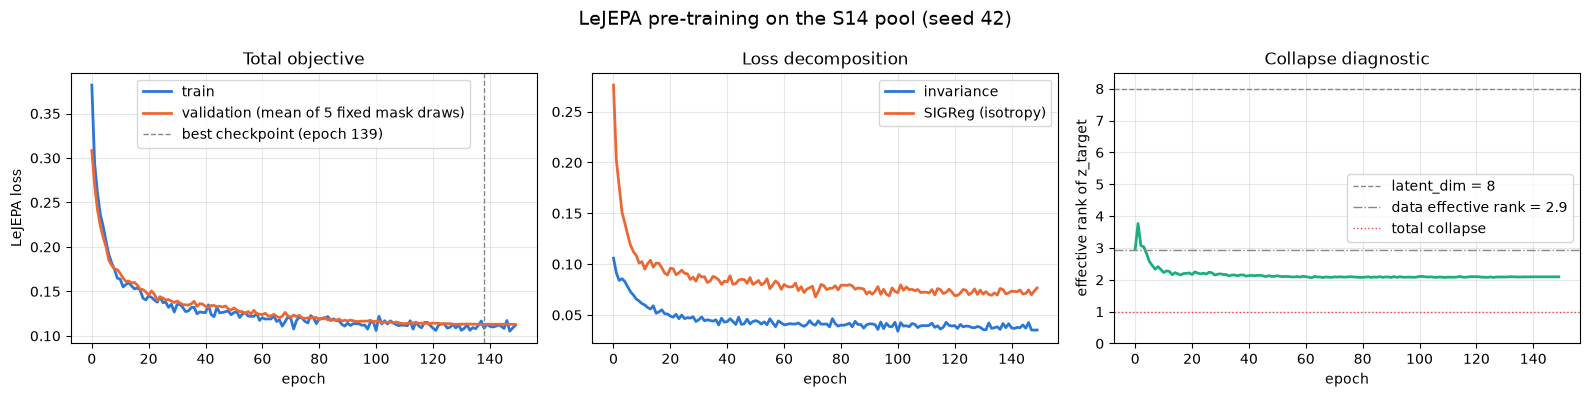

In [6]:
# =============================================================================
# STEP 3b: Pre-training diagnostics
# =============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
best_ep = int(np.argmin(history['val']))
ax1.plot(history['train'], color=BLUE, lw=2, label='train')
ax1.plot(history['val'], color=ORANGE, lw=2, label=f'validation (mean of {N_VAL_MASK_DRAWS} fixed mask draws)')
ax1.axvline(best_ep, ls='--', c=GRAY, lw=1, label=f'best checkpoint (epoch {best_ep + 1})')
ax1.set_xlabel('epoch'); ax1.set_ylabel('LeJEPA loss'); ax1.set_title('Total objective'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history['invariance'], color=BLUE, lw=2, label='invariance')
ax2.plot(history['isotropy'], color=ORANGE, lw=2, label='SIGReg (isotropy)')
ax2.set_xlabel('epoch'); ax2.set_title('Loss decomposition'); ax2.legend(); ax2.grid(alpha=0.3)
ax3.plot(history['eff_rank'], color=GREEN, lw=2)
ax3.axhline(LATENT_DIM, ls='--', c=GRAY, lw=1, label=f'latent_dim = {LATENT_DIM}')
ax3.axhline(eff_rank_data, ls='-.', c=GRAY, lw=1, label=f'data effective rank = {eff_rank_data:.1f}')
ax3.axhline(1.0, ls=':', c=RED, lw=1, label='total collapse')
ax3.set_ylim(0, LATENT_DIM + 0.5); ax3.set_xlabel('epoch'); ax3.set_ylabel('effective rank of z_target')
ax3.set_title('Collapse diagnostic'); ax3.legend(); ax3.grid(alpha=0.3)
plt.suptitle(f'LeJEPA pre-training on the {MAIN_EQUIPMENT} pool (seed {SEED})', fontsize=14)
plt.tight_layout(); plt.show()

## STEP 4 — Active learning on the pool, classifier judged on the tuning partition

Only pool records are scored and queried. The downstream forest is fitted on the
queried records and scored on the **tuning** partition during development.
Random sampling and the PCA baseline draw from the same pool and are judged on
the same tuning records. The budget is 300 labelled *part records*; the number of
distinct (machine, timestamp) groups among them is reported alongside.

In [7]:
# =============================================================================
# STEP 4.0: Sanity check — the model about to be scored with IS the trained one
# =============================================================================
u_enc, u_pred = make_models(input_dim, LATENT_DIM, ENCODER_HIDDEN, PREDICTOR_HIDDEN)
gen = torch.Generator().manual_seed(0)
x_check = X_tensor[pool_idx][torch.randperm(len(pool_idx), generator=gen)[:512]]
mask_check = sample_group_mask(len(x_check), GROUP_MATRIX, KEEP_PROB, generator=gen)
rows = []
with torch.no_grad():
    for name, e, p in [('trained (STEP 3)', encoder, predictor), ('untrained (fresh init)', u_enc.eval(), u_pred.eval())]:
        z_t = encode_full(e, x_check)
        mse = torch.mean((z_t - p(e(x_check, mask_check))) ** 2).item()
        rows.append((name, mse, 100 * mse / z_t.var(dim=0).mean().item()))
print(f"{'model pair':<26}{'invariance MSE':>16}{'as % of latent variance':>26}")
for name, mse, rel in rows:
    print(f"{name:<26}{mse:>16.4f}{rel:>25.1f}%")
assert rows[0][2] < rows[1][2] / 3, "the encoder does not look trained: re-run STEP 3"
print("\nOK: the trained pair explains far more of the latent than a fresh one.")

model pair                  invariance MSE   as % of latent variance
trained (STEP 3)                    0.0384                     10.0%
untrained (fresh init)              0.1897                    501.4%

OK: the trained pair explains far more of the latent than a fresh one.


acquisition_score(mode='mc', draws=50) on 2940 pool records in 0.08 s
median score  pass 0.390  |  defect 0.444
ranks of the 32 pool defects (1 = most uncertain): [   8   21   23   38  100  104  157  175  326  361  509  599  600  608
  668  775 1138 1475 1569 2116] ...
8 pool defects inside the top-300; random would place 3.3 there on average.


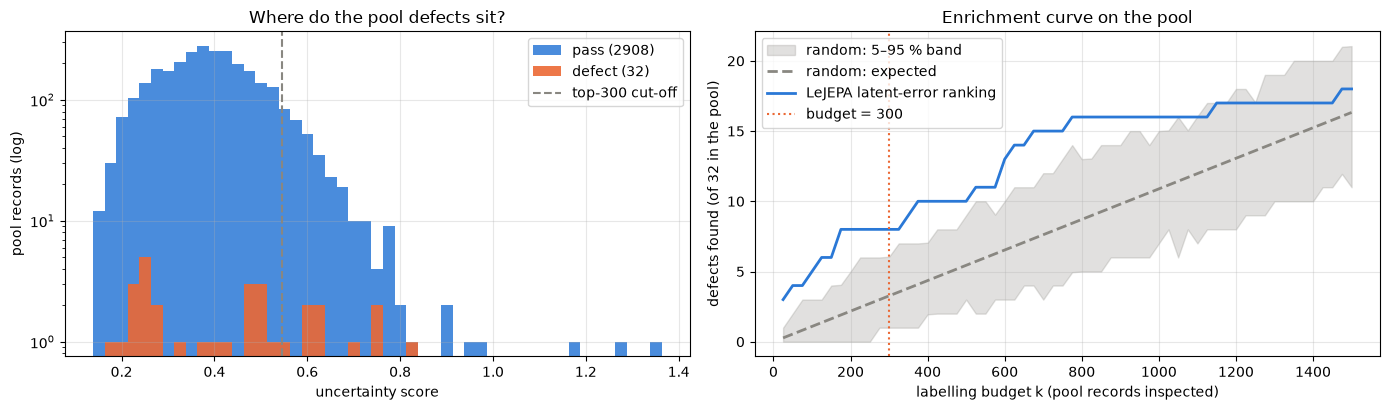

In [8]:
# =============================================================================
# STEP 4.2: Score the POOL (no labels), then diagnose with labels
# =============================================================================
t0 = time.time()
pool_scores = acquisition_score(encoder, predictor, X_tensor[pool_idx], GROUP_MATRIX,
                                mode=SCORING_MODE, n_draws=N_MASK_DRAWS, seed=SEED)
t_score = time.time() - t0
y_pool, type_pool = y[pool_idx], defect_type[pool_idx]
n_pool, n_def_pool = len(pool_idx), int(y_pool.sum())
print(f"acquisition_score(mode='{SCORING_MODE}', draws={N_MASK_DRAWS}) on {n_pool} pool records in {t_score:.2f} s")
print(f"median score  pass {np.median(pool_scores[y_pool == 0]):.3f}  |  defect {np.median(pool_scores[y_pool == 1]):.3f}")
rank_desc = np.lexsort((pool_idx, -pool_scores))
rank_of = np.empty(n_pool, dtype=int); rank_of[rank_desc] = np.arange(1, n_pool + 1)
print(f"ranks of the {n_def_pool} pool defects (1 = most uncertain): {np.sort(rank_of[y_pool == 1])[:20]} ...")
print(f"{int((rank_of[y_pool == 1] <= LABELING_BUDGET).sum())} pool defects inside the top-{LABELING_BUDGET}; "
      f"random would place {LABELING_BUDGET * y_pool.mean():.1f} there on average.")

budgets = np.arange(25, 1501, 25)
found = np.array([y_pool[rank_desc[:k]].sum() for k in budgets])
rng_curve = np.random.RandomState(SEED)
rand_draws = np.array([[y_pool[rng_curve.choice(n_pool, k, replace=False)].sum() for k in budgets] for _ in range(200)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2))
bins = np.linspace(pool_scores.min(), pool_scores.max(), 50)
ax1.hist(pool_scores[y_pool == 0], bins=bins, color=BLUE, alpha=0.85, label=f'pass ({n_pool - n_def_pool})')
ax1.hist(pool_scores[y_pool == 1], bins=bins, color=ORANGE, alpha=0.9, label=f'defect ({n_def_pool})')
ax1.axvline(np.sort(pool_scores)[-LABELING_BUDGET], color=GRAY, ls='--', lw=1.5, label=f'top-{LABELING_BUDGET} cut-off')
ax1.set_yscale('log'); ax1.set_xlabel('uncertainty score'); ax1.set_ylabel('pool records (log)')
ax1.set_title('Where do the pool defects sit?'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.fill_between(budgets, np.percentile(rand_draws, 5, axis=0), np.percentile(rand_draws, 95, axis=0), color=GRAY, alpha=0.25, label='random: 5–95 % band')
ax2.plot(budgets, budgets * y_pool.mean(), color=GRAY, lw=2, ls='--', label='random: expected')
ax2.plot(budgets, found, color=BLUE, lw=2, label='LeJEPA latent-error ranking')
ax2.axvline(LABELING_BUDGET, color=ORANGE, ls=':', lw=1.5, label=f'budget = {LABELING_BUDGET}')
ax2.set_xlabel('labelling budget k (pool records inspected)'); ax2.set_ylabel(f'defects found (of {n_def_pool} in the pool)')
ax2.set_title('Enrichment curve on the pool'); ax2.legend(loc='upper left'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Queried 300 pool records = 222 distinct (machine, timestamp) groups.
Defects found: 8 (2.7% vs 1.09% pool base rate) -> enrichment x2.5
  by type: gas 2 | short shot 2 | startup 4   (pool holds {'gas': 18, 'short_shot': 10, 'startup': 4})
  row numbers (S14 index): [80, 103, 118, 2467, 2468, 2471, 2472, 5188]
  -> roughly 5 production event(s)



training rows : 300 (defects 8) | tuning rows: 982 (defects 13)
tuning AP     : 0.3943   (chance = 0.0132)   [0.7 s]

     k  defects caught   of   precision   recall
    10               5   13       0.500    0.385
    25               5   13       0.200    0.385
    50               7   13       0.140    0.538
   100               8   13       0.080    0.615
   200               9   13       0.045    0.692
   400              10   13       0.025    0.769


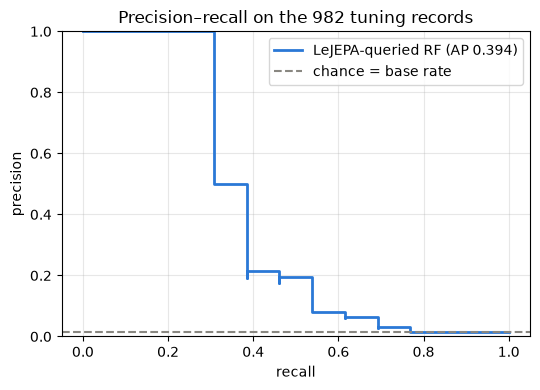

In [9]:
# =============================================================================
# STEP 4.3: Query the 300 highest-scoring POOL records; 4.4: forest judged on the TUNING set
# =============================================================================
def rf_matrix(idx, use_part_name):
    '''Forest input: standardised sensors, plus one-hot part identity when requested.'''
    return np.hstack([X_scaled[idx], PART_ONEHOT[idx]]) if use_part_name else X_scaled[idx]

def rf_feature_names(use_part_name):
    return feature_names + part_feature_names if use_part_name else list(feature_names)

def fit_and_score(query_idx, holdout_idx, rf_seed, use_part_name=RF_USE_PART_NAME):
    '''Fit a balanced Random Forest on the queried records; return (clf, holdout_idx, AP on holdout).'''
    clf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=rf_seed,
                                 class_weight='balanced_subsample', n_jobs=RF_N_JOBS)
    clf.fit(rf_matrix(query_idx, use_part_name), y[query_idx])
    proba = (np.zeros(len(holdout_idx)) if len(clf.classes_) == 1
             else clf.predict_proba(rf_matrix(holdout_idx, use_part_name))[:, 1])
    return clf, holdout_idx, average_precision_score(y[holdout_idx], proba)

def describe_query(query_idx):
    '''Discovery metrics of one query set: defects by type and distinct groups.'''
    d = {'total_defects': int(y[query_idx].sum())}
    d.update({t: int((defect_type[query_idx] == t).sum()) for t in DEFECT_TYPES})
    d['distinct_groups'] = int(len(np.unique(groups[query_idx])))
    return d

def evaluate_query(query_idx, holdout_idx, rf_seed, use_part_name=RF_USE_PART_NAME):
    '''Discovery metrics + downstream AP in one dict (the row format of every results table).'''
    d = describe_query(query_idx)
    d['ap'] = fit_and_score(query_idx, holdout_idx, rf_seed, use_part_name)[2]
    return d

query_indices = top_k(pool_scores, pool_idx, LABELING_BUDGET)
X_active_learning, y_active_learning = X_scaled[query_indices], y[query_indices]
q = describe_query(query_indices)
n_found = q['total_defects']
print(f"Queried {LABELING_BUDGET} pool records = {q['distinct_groups']} distinct (machine, timestamp) groups.")
print(f"Defects found: {n_found} ({n_found / LABELING_BUDGET * 100:.1f}% vs {y_pool.mean() * 100:.2f}% pool base rate) "
      f"-> enrichment x{n_found / (LABELING_BUDGET * y_pool.mean()):.1f}")
print(f"  by type: gas {q['gas']} | short shot {q['short_shot']} | startup {q['startup']}   "
      f"(pool holds {dict(zip(DEFECT_TYPES, [int((type_pool == t).sum()) for t in DEFECT_TYPES]))})")
q_def = query_indices[y[query_indices] == 1]
n_events = 1 + int((np.diff(q_def) > 5).sum()) if len(q_def) else 0
print(f"  row numbers (S14 index): {q_def.tolist()}\n  -> roughly {n_events} production event(s)")

t0 = time.time()
clf, _, auprc_active = fit_and_score(query_indices, tuning_idx, SEED)
proba_active = clf.predict_proba(rf_matrix(tuning_idx, RF_USE_PART_NAME))[:, 1]
n_pos_tuning = int(y[tuning_idx].sum())
print(f"\ntraining rows : {len(query_indices)} (defects {n_found}) | tuning rows: {len(tuning_idx)} (defects {n_pos_tuning})")
print(f"tuning AP     : {auprc_active:.4f}   (chance = {y[tuning_idx].mean():.4f})   [{time.time() - t0:.1f} s]")
order = np.argsort(-proba_active)
print(f"\n{'k':>6}{'defects caught':>16}{'of':>5}{'precision':>12}{'recall':>9}")
for k in [10, 25, 50, 100, 200, 400]:
    caught = int(y[tuning_idx][order[:k]].sum())
    print(f"{k:>6}{caught:>16}{n_pos_tuning:>5}{caught / k:>12.3f}{caught / n_pos_tuning:>9.3f}")
prec, rec, _ = precision_recall_curve(y[tuning_idx], proba_active)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.step(rec, prec, where='post', color=BLUE, lw=2, label=f'LeJEPA-queried RF (AP {auprc_active:.3f})')
ax.axhline(y[tuning_idx].mean(), color=GRAY, ls='--', lw=1.5, label='chance = base rate')
ax.set_xlabel('recall'); ax.set_ylabel('precision'); ax.set_ylim(0, 1)
ax.set_title(f'Precision–recall on the {len(tuning_idx)} tuning records'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# =============================================================================
# STEP 4.5: Controls on the same pool / tuning partitions: random-300 (10 draws) and PCA
# =============================================================================
rng = np.random.RandomState(SEED)
rand_rows = []
for d in range(N_RANDOM_BASELINE_DRAWS):
    ridx = np.sort(rng.choice(pool_idx, LABELING_BUDGET, replace=False))
    rand_rows.append(evaluate_query(ridx, tuning_idx, SEED))
rand_df = pd.DataFrame(rand_rows)
pca_query = top_k(pca_recon_err[pool_idx], pool_idx, LABELING_BUDGET)
pca_row = evaluate_query(pca_query, tuning_idx, SEED)

print(f"--- budget {LABELING_BUDGET} from the pool, forest judged on the tuning set (seed {SEED}) ---")
print(f"{'strategy':<30}{'defects':>9}{'gas':>5}{'short':>7}{'startup':>9}{'groups':>8}{'tuning AP':>12}")
print(f"{'LeJEPA latent error':<30}{q['total_defects']:>9}{q['gas']:>5}{q['short_shot']:>7}{q['startup']:>9}{q['distinct_groups']:>8}{auprc_active:>12.4f}")
print(f"{'random (10 draws, mean)':<30}{rand_df.total_defects.mean():>9.1f}{rand_df.gas.mean():>5.1f}{rand_df.short_shot.mean():>7.1f}"
      f"{rand_df.startup.mean():>9.1f}{rand_df.distinct_groups.mean():>8.0f}{rand_df.ap.mean():>12.4f} +- {rand_df.ap.std():.4f}")
print(f"{f'PCA({pca_k}) reconstruction error':<30}{pca_row['total_defects']:>9}{pca_row['gas']:>5}{pca_row['short_shot']:>7}{pca_row['startup']:>9}{pca_row['distinct_groups']:>8}{pca_row['ap']:>12.4f}")
print("\nOne seed is not evidence; STEP 6 gives the error bars.")

--- budget 300 from the pool, forest judged on the tuning set (seed 42) ---
strategy                        defects  gas  short  startup  groups   tuning AP
LeJEPA latent error                   8    2      2        4     222      0.3943
random (10 draws, mean)             4.3  2.4    1.4      0.5     286      0.1776 +- 0.1287
PCA(3) reconstruction error          11    5      2        4     151      0.2124

One seed is not evidence; STEP 6 gives the error bars.


In [11]:
# =============================================================================
# STEP 4.6b (diagnostic): exact expectation over all block masks vs Monte-Carlo, on the pool
# =============================================================================
t0 = time.time()
exact_pool, per_mask_err, keep_patterns = latent_uncertainty_exact(encoder, predictor, X_tensor[pool_idx], GROUP_MATRIX, return_details=True)
t_exact = time.time() - t0
top_exact = set(top_k(exact_pool, pool_idx, LABELING_BUDGET))
print(f"exact score over {per_mask_err.shape[0]} masks x {n_pool} pool records in {t_exact:.2f} s; "
      f"defects in its top-{LABELING_BUDGET}: {int(y[list(top_exact)].sum())}")
print(f"\n{'mc seed':<10}{'draws':>6}{'Spearman vs exact':>18}{'top-300 overlap':>18}{'defects':>9}{'time s':>8}")
for n_dr in (10, 50):
    for s in range(5):
        t0 = time.time()
        mc = latent_uncertainty(encoder, predictor, X_tensor[pool_idx], GROUP_MATRIX, n_draws=n_dr, generator=torch.Generator().manual_seed(s))
        tm = time.time() - t0
        top_mc = set(top_k(mc, pool_idx, LABELING_BUDGET))
        print(f"{s:<10}{n_dr:>6}{spearmanr(mc, exact_pool).correlation:>18.3f}{len(top_mc & top_exact):>14}/{LABELING_BUDGET}{int(y[list(top_mc)].sum()):>9}{tm:>8.2f}")

hidden = (keep_patterns == 0)
block_effect = torch.stack([per_mask_err[hidden[:, g]].mean(0) - per_mask_err[~hidden[:, g]].mean(0) for g in range(N_GROUPS)], dim=1).numpy()
hdr = "".join(f"{f'B{b}({n})':>10}" for b, n in zip(BLOCK_IDS, BLOCK_SIZE))
print(f"\nerror increase when a block is hidden (mean over pool records):\n{'':<18}{hdr}")
for name, sel in [('defects', y_pool == 1), ('passes', y_pool == 0)]:
    print(f"{name:<18}" + "".join(f"{v:>10.3f}" for v in block_effect[sel].mean(0)))

exact score over 62 masks x 2940 pool records in 0.05 s; defects in its top-300: 9

mc seed    draws Spearman vs exact   top-300 overlap  defects  time s
0             10             0.662           137/300        7    0.02
1             10             0.642           139/300        7    0.02
2             10             0.656           138/300        8    0.02
3             10             0.674           131/300       10    0.02
4             10             0.645           121/300        7    0.02


0             50             0.880           217/300       10    0.11
1             50             0.882           213/300       10    0.10
2             50             0.884           210/300       10    0.09


3             50             0.886           192/300        7    0.31
4             50             0.886           208/300       10    0.12

error increase when a block is hidden (mean over pool records):
                       B1(2)     B2(1)     B3(2)     B4(1)    B5(17)     B6(1)
defects                0.172     0.002     0.271     0.240     0.259     0.006
passes                 0.164     0.059     0.226     0.128     0.278     0.035


In [12]:
# =============================================================================
# STEP 4.6c (diagnostic): does the LeJEPA score beat a trivial anomaly score on the pool?
# =============================================================================
l2_pool = np.linalg.norm(X_scaled[pool_idx], axis=1)
candidates = {f'LeJEPA latent error ({SCORING_MODE}-{N_MASK_DRAWS})': pool_scores,
              'LeJEPA latent error (exact)': exact_pool,
              f'PCA({pca_k}) reconstruction error': pca_recon_err[pool_idx],
              '‖x‖ distance from mean cycle': l2_pool}
print(f"{'ranking score (pool)':<34}{'defects in top-300':>20}{'gas/short/startup':>20}{'groups':>8}{'AP as detector':>16}")
for name, s in candidates.items():
    top = top_k(s, pool_idx, LABELING_BUDGET); dq = describe_query(top)
    by_type = f"{dq['gas']}/{dq['short_shot']}/{dq['startup']}"
    print(f"{name:<34}{dq['total_defects']:>20}{by_type:>20}{dq['distinct_groups']:>8}{average_precision_score(y_pool, s):>16.4f}")
print(f"{'random expectation':<34}{LABELING_BUDGET * y_pool.mean():>20.1f}{'':>20}{'':>8}{y_pool.mean():>16.4f}")
print(f"\nSpearman(LeJEPA exact, PCA recon err) = {spearmanr(exact_pool, pca_recon_err[pool_idx]).correlation:+.3f}")
print(f"Spearman(LeJEPA exact, ‖x‖)           = {spearmanr(exact_pool, l2_pool).correlation:+.3f}")

ranking score (pool)                defects in top-300   gas/short/startup  groups  AP as detector
LeJEPA latent error (mc-50)                          8               2/2/4     222          0.0314
LeJEPA latent error (exact)                          9               4/1/4     152          0.0460
PCA(3) reconstruction error                         11               5/2/4     151          0.1222
‖x‖ distance from mean cycle                        11               6/3/2     155          0.0458
random expectation                                 3.3                                      0.0109

Spearman(LeJEPA exact, PCA recon err) = +0.493
Spearman(LeJEPA exact, ‖x‖)           = -0.290


## STEP 5 — Explainability (SHAP) on the physical sensors

Unchanged. If `RF_USE_PART_NAME` is on, the part-identity columns are part of the
forest input, so they receive SHAP values too; they are reported **separately as
metadata** and never mixed into the sensor ranking.

SHAP values: (300, 24) (queried records x sensors)  [0.2 s]

Top 5 sensors by mean |SHAP|:
  Cushion_Position             0.0470   (block 5)
  Max_Switch_Over_Pressure     0.0439   (block 5)
  Max_Injection_Pressure       0.0438   (block 3)
  Average_Back_Pressure        0.0413   (block 4)
  Max_Back_Pressure            0.0351   (block 5)

Summed by correlated block:
  block 5 (17 sensors): 0.3531
  block 3 (2 sensors): 0.0665
  block 4 (1 sensors): 0.0413
  block 1 (2 sensors): 0.0410


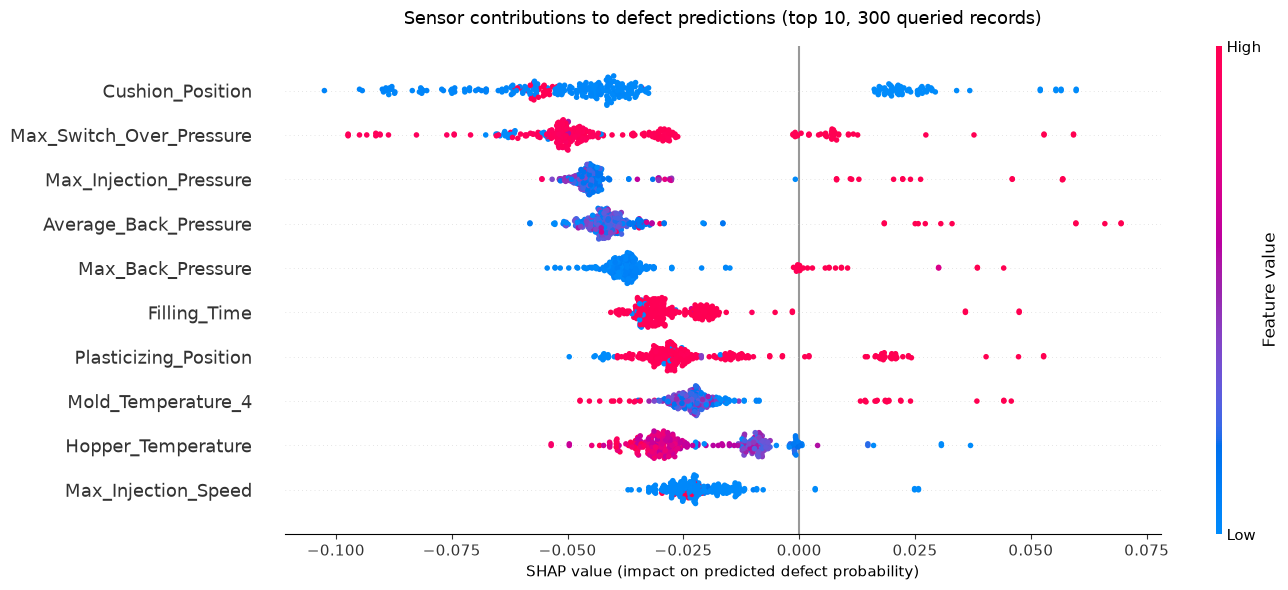

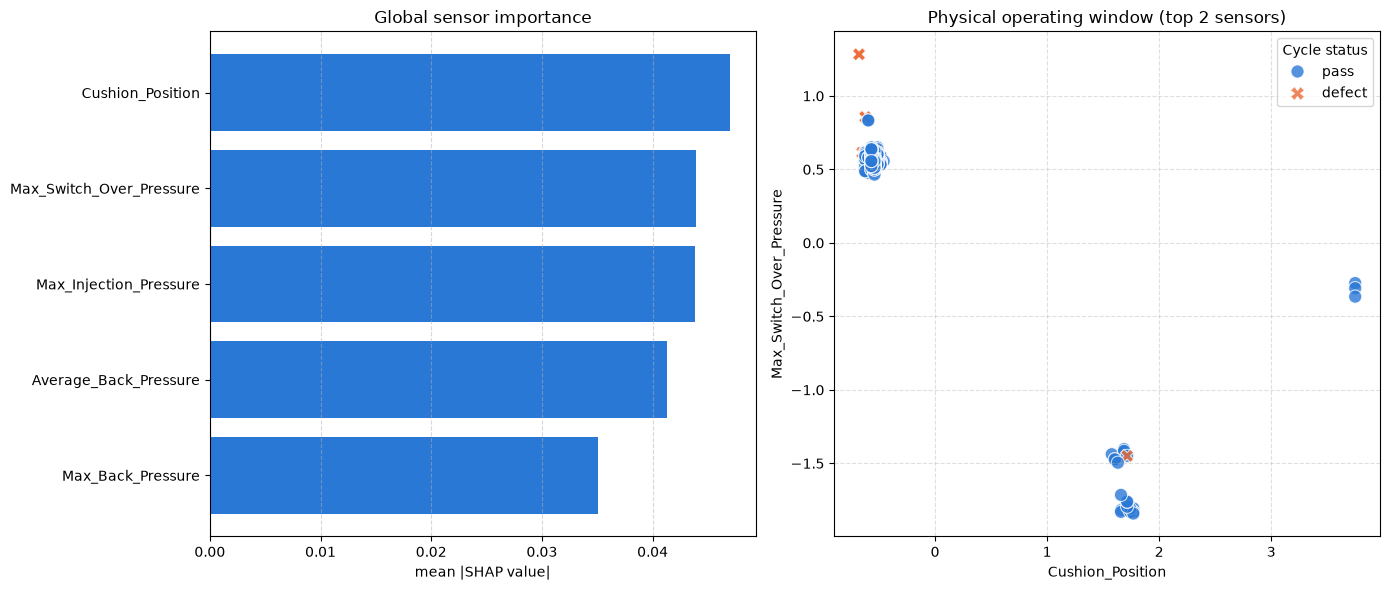

In [13]:
# =============================================================================
# STEP 5: SHAP values on the raw sensors (positive = defect class)
# =============================================================================
def shap_positive(model, data):
    vals = shap.TreeExplainer(model).shap_values(data)
    if isinstance(vals, list):
        return np.asarray(vals[1])
    vals = np.asarray(vals)
    return vals[:, :, 1] if vals.ndim == 3 else vals

t0 = time.time()
rf_names = rf_feature_names(RF_USE_PART_NAME)
X_al_rf = rf_matrix(query_indices, RF_USE_PART_NAME)
shap_values_all = shap_positive(clf, X_al_rf)
assert shap_values_all.shape == X_al_rf.shape, shap_values_all.shape
n_sens = len(feature_names)
shap_values_pos = shap_values_all[:, :n_sens]                   # sensors only
shap_part = shap_values_all[:, n_sens:] if RF_USE_PART_NAME else None
X_al_df = pd.DataFrame(X_active_learning, columns=feature_names)
importance_df = (pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(shap_values_pos).mean(axis=0),
                               'Block': [block_of[f] for f in feature_names]}).sort_values('Importance'))
block_importance = importance_df.groupby('Block')['Importance'].sum().sort_values(ascending=False)
print(f"SHAP values: {shap_values_pos.shape} (queried records x sensors)  [{time.time() - t0:.1f} s]")
print("\nTop 5 sensors by mean |SHAP|:")
for _, r in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {r['Feature']:<28} {r['Importance']:.4f}   (block {r['Block']})")
print("\nSummed by correlated block:")
for b, v in block_importance.head(4).items():
    print(f"  block {b} ({BLOCK_SIZE[list(BLOCK_IDS).index(b)]} sensors): {v:.4f}")
if RF_USE_PART_NAME:
    print(f"\nPart identity (metadata) mean |SHAP|: {dict(zip(part_feature_names, np.abs(shap_part).mean(0).round(4)))}")

fig = plt.figure(figsize=(14, 6)); ax = plt.gca()
shap.summary_plot(shap_values_pos, X_al_df, max_display=10, plot_size=None, show=False)
plt.title(f"Sensor contributions to defect predictions (top 10, {LABELING_BUDGET} queried records)", fontsize=13, pad=16)
ax.set_xlabel("SHAP value (impact on predicted defect probability)", fontsize=11)
plt.tight_layout(); plt.show()

top5_df = importance_df.tail(5)
feat_x, feat_y = importance_df['Feature'].iloc[-1], importance_df['Feature'].iloc[-2]
plot_df = X_al_df.copy(); plot_df['Cycle status'] = np.where(y_active_learning == 1, 'defect', 'pass')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(top5_df['Feature'], top5_df['Importance'], color=BLUE); ax1.set_xlabel('mean |SHAP value|'); ax1.set_title('Global sensor importance'); ax1.grid(axis='x', linestyle='--', alpha=0.5)
sns.scatterplot(data=plot_df, x=feat_x, y=feat_y, hue='Cycle status', hue_order=['pass', 'defect'], palette={'pass': BLUE, 'defect': ORANGE},
                style='Cycle status', markers={'pass': 'o', 'defect': 'X'}, s=90, alpha=0.8, ax=ax2)
ax2.set_title('Physical operating window (top 2 sensors)'); ax2.grid(linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## STEP 6 — The corrected reference configuration (five seeds)

The baseline every experiment is compared against. Per seed: pre-train on the
pool (group-aware validation split), score the pool, query the top-300, fit the
forest, judge it on the tuning partition. Random and PCA strategies use the same
pool and the same tuning records. The per-seed models are kept in memory because
Experiments A and C reuse them without retraining.

Decided here, before any experiment is run: **the primary criterion is defect
discovery within the budget (total defects per 300 queries), the secondary
criterion is downstream AP on the tuning partition.** The paper's main claim is
label-efficient defect discovery; AP from a 300-row forest with ~10 positives is
too noisy to rank configurations on its own.

In [14]:
# =============================================================================
# STEP 6: Reference configuration, five seeds; the experiment harness
# =============================================================================
RESULT_COLUMNS = ['Configuration', 'Seed', 'Total defects / 300', 'Gas', 'Short shot', 'Startup',
                  'Distinct groups queried', 'Downstream AP', 'Effective rank', 'Latent variance', 'Runtime']
ALL_RESULTS = []                       # every row of every configuration, in the fixed column order
PRIMARY, SECONDARY = 'Total defects / 300', 'Downstream AP'

def result_row(config_name, seed, metrics, eff_rank, latent_var, runtime):
    return {'Configuration': config_name, 'Seed': seed, 'Total defects / 300': metrics['total_defects'],
            'Gas': metrics['gas'], 'Short shot': metrics['short_shot'], 'Startup': metrics['startup'],
            'Distinct groups queried': metrics['distinct_groups'], 'Downstream AP': metrics['ap'],
            'Effective rank': eff_rank, 'Latent variance': latent_var, 'Runtime': runtime}

def run_configuration(config_name, cfg, seeds, fs, holdout_idx, verbose=True):
    '''Train / score / query / evaluate one configuration for every seed on the given feature set.

    Networks are re-created per seed and every setting is passed explicitly from `cfg`.
    Returns (rows, models) where models[seed] = (encoder, predictor, pool scores, query indices).
    '''
    rows, models = [], {}
    Xp, gm = fs['X_tensor'][pool_idx], fs['GROUP_MATRIX']
    if verbose:
        print(f"[{config_name}]  {cfg}")
        print(f"{'seed':<6}{'defects':>9}{'gas/short/startup':>19}{'groups':>8}{'AP':>9}{'eff.rank':>10}{'lat.var':>9}{'time':>7}")
    for seed in seeds:
        t0 = time.time()
        enc, pred, _, info = pretrain_lejepa(Xp, seed, groups=groups[pool_idx], group_matrix=gm, verbose=False, **train_kwargs(cfg))
        scores = acquisition_score(enc, pred, Xp, gm, mode=cfg['scoring_mode'], n_draws=cfg['n_mask_draws'], seed=seed)
        qidx = top_k(scores, pool_idx, LABELING_BUDGET)
        with torch.no_grad():
            z = encode_full(enc, Xp).numpy()
        er, lv = effective_rank(z), float(z.var(axis=0).mean())
        m = evaluate_query(qidx, holdout_idx, seed, cfg['rf_use_part_name'])
        rt = time.time() - t0
        rows.append(result_row(config_name, seed, m, er, lv, rt))
        models[seed] = (enc, pred, scores, qidx)
        if verbose:
            by_type = f"{m['gas']}/{m['short_shot']}/{m['startup']}"
            print(f"{seed:<6}{m['total_defects']:>9}{by_type:>19}{m['distinct_groups']:>8}{m['ap']:>9.4f}{er:>10.2f}{lv:>9.3f}{rt:>6.0f}s", flush=True)
    return rows, models

def baseline_queries(seed, fs):
    '''The two label-free controls for one seed: random-300 and PCA top-300, both from the pool.'''
    rand_q = np.sort(np.random.RandomState(seed).choice(pool_idx, LABELING_BUDGET, replace=False))
    pca_q = top_k(fs['pca_recon_err'][pool_idx], pool_idx, LABELING_BUDGET)
    return {'Random sampling': rand_q, f"PCA({fs['pca_k']}) reconstruction error": pca_q}

def summarise(rows_or_df, by='Configuration'):
    '''mean +- sd per configuration for the fixed columns.'''
    d = pd.DataFrame(rows_or_df) if not isinstance(rows_or_df, pd.DataFrame) else rows_or_df
    num = [c for c in RESULT_COLUMNS if c not in ('Configuration', 'Seed')]
    g = d.groupby(by, sort=False)[num]
    out = g.mean().round(3).astype(str) + ' ± ' + g.std().fillna(0).round(3).astype(str)
    out['n seeds'] = g.size()
    return out

# ---- the reference run -------------------------------------------------------
t_base = time.time()
base_rows, BASE_MODELS = run_configuration('Baseline', BASE_CFG, SEEDS, FS, tuning_idx)
ctrl_rows = []
for seed in SEEDS:
    for name, qidx in baseline_queries(seed, FS).items():
        m = evaluate_query(qidx, tuning_idx, seed, BASE_CFG['rf_use_part_name'])
        ctrl_rows.append(result_row(name, seed, m, np.nan, np.nan, np.nan))
ALL_RESULTS += base_rows + ctrl_rows
print(f"\n--- Reference configuration vs controls, {len(SEEDS)} seeds, budget {LABELING_BUDGET}, judged on tuning ({time.time() - t_base:.0f} s) ---")
print(summarise(base_rows + ctrl_rows).to_string())

# save BEFORE anything is changed
pd.DataFrame(base_rows + ctrl_rows, columns=RESULT_COLUMNS).to_csv(f'{RESULTS_DIR}/baseline_results.csv', index=False)
with open(f'{RESULTS_DIR}/baseline_config.json', 'w') as fh:
    json.dump({k: (list(v) if isinstance(v, tuple) else v) for k, v in BASE_CFG.items()}
              | {'seeds': SEEDS, 'budget': LABELING_BUDGET, 'equipment': MAIN_EQUIPMENT}, fh, indent=2)
print(f"\nSaved {RESULTS_DIR}/baseline_results.csv and baseline_config.json")

[Baseline]  {'drop_dead_sensors': True, 'latent_dim': 8, 'enc_hidden': (64, 32), 'pred_hidden': 32, 'keep_prob': 0.5, 'lam': 1.0, 'n_mask_draws': 50, 'scoring_mode': 'mc', 'lr': 0.003, 'weight_decay': 0.0001, 'batch_size': 256, 'rf_use_part_name': False}
seed    defects  gas/short/startup  groups       AP  eff.rank  lat.var   time


0            14              6/4/4     223   0.4224      2.04    0.393    12s


1            11              5/3/3     218   0.4132      2.09    0.392    12s


2             9              3/2/4     211   0.3260      2.09    0.393    12s


3            12              6/2/4     215   0.4069      2.12    0.395    13s


4             9              3/2/4     216   0.3286      2.09    0.383    12s



--- Reference configuration vs controls, 5 seeds, budget 300, judged on tuning (67 s) ---
                            Total defects / 300          Gas   Short shot      Startup Distinct groups queried  Downstream AP Effective rank Latent variance         Runtime  n seeds
Configuration                                                                                                                                                                        
Baseline                           11.0 ± 2.121  4.6 ± 1.517  2.6 ± 0.894  3.8 ± 0.447           216.6 ± 4.393  0.379 ± 0.048  2.088 ± 0.029   0.391 ± 0.004  12.243 ± 0.171        5
Random sampling                     3.4 ± 1.517  2.2 ± 1.095  1.2 ± 0.837    0.0 ± 0.0           283.2 ± 3.271  0.093 ± 0.072            NaN             NaN             NaN        5
PCA(3) reconstruction error          11.0 ± 0.0    5.0 ± 0.0    2.0 ± 0.0    4.0 ± 0.0             151.0 ± 0.0  0.209 ± 0.006            NaN             NaN             NaN        5

## STEP 9 — Experiments, one setting at a time

| Exp. | Question | Retraining |
| --- | --- | --- |
| A | Does averaging more masks make the selected records more stable? (10 vs 50 draws vs exact) | No: reuses the five baseline models |
| B | Are near-constant sensors distracting the model? (`DROP_DEAD_SENSORS = False`) | Yes, from STEP 1 (new feature set) |
| C | Does part identity help the classifier? (`RF_USE_PART_NAME = True`) | Forests only, same queried records |
| D | Does a tighter bottleneck help acquisition? (`LATENT_DIM = 4`) | Yes |
| E | Is the regularisation balance right? (`LAMBDA_SIGREG` 0.5 / 2.0) | Yes |
| F | Does a wider encoder help? (`ENCODER_HIDDEN = (128, 64)`) | Yes (optional) |

Each row of every table is one seed. Every experiment is compared against the
corrected baseline of STEP 6, on the same tuning records.

In [15]:
# =============================================================================
# STEP 9A: Experiment A — number of mask draws (no retraining)
# =============================================================================
exp_a_rows = []
for seed, (enc, pred, _, _) in BASE_MODELS.items():
    Xp = X_tensor[pool_idx]
    t0 = time.time(); exact = latent_uncertainty_exact(enc, pred, Xp, GROUP_MATRIX); t_ex = time.time() - t0
    q_exact = top_k(exact, pool_idx, LABELING_BUDGET); top_ex = set(q_exact)
    d = describe_query(q_exact)
    exp_a_rows.append({'run': 'A3 exact', 'model seed': seed, 'mask seed': np.nan, 'overlap with exact top-300': LABELING_BUDGET,
                       **d, 'scoring time s': t_ex})
    for run, n_dr in (('A1 mc-10', 10), ('A2 mc-50', 50)):
        for mask_seed in range(5):
            t0 = time.time()
            sc = latent_uncertainty(enc, pred, Xp, GROUP_MATRIX, n_draws=n_dr, generator=torch.Generator().manual_seed(mask_seed))
            tm = time.time() - t0
            qm = top_k(sc, pool_idx, LABELING_BUDGET)
            exp_a_rows.append({'run': run, 'model seed': seed, 'mask seed': mask_seed,
                               'overlap with exact top-300': len(set(qm) & top_ex), **describe_query(qm), 'scoring time s': tm})
exp_a = pd.DataFrame(exp_a_rows)
exp_a.to_csv(f'{RESULTS_DIR}/experiment_A_mask_draws.csv', index=False)
cols = ['overlap with exact top-300', 'total_defects', 'gas', 'short_shot', 'startup', 'distinct_groups', 'scoring time s']
g = exp_a.groupby('run', sort=False)[cols]
exp_a_summary = (g.mean().round(2).astype(str) + ' ± ' + g.std().round(2).astype(str))
print("Experiment A — per run, mean ± sd over 5 model seeds x 5 mask seeds (exact: 5 model seeds):")
print(exp_a_summary.to_string())

# per-model-seed stability of the selected set across mask seeds (Jaccard of the top-300 between mask seeds)
def mean_pairwise_jaccard(sets):
    s = list(sets); v = []
    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            v.append(len(s[i] & s[j]) / len(s[i] | s[j]))
    return float(np.mean(v)) if v else 1.0
stab = {}
for run, n_dr in (('A1 mc-10', 10), ('A2 mc-50', 50)):
    js = []
    for seed, (enc, pred, _, _) in BASE_MODELS.items():
        sets = [set(top_k(latent_uncertainty(enc, pred, X_tensor[pool_idx], GROUP_MATRIX, n_draws=n_dr,
                                             generator=torch.Generator().manual_seed(ms)), pool_idx, LABELING_BUDGET)) for ms in range(5)]
        js.append(mean_pairwise_jaccard(sets))
    stab[run] = (np.mean(js), np.std(js))
print("\nStability of the top-300 across mask seeds (mean pairwise Jaccard, mean ± sd over model seeds):")
for run, (m_, s_) in stab.items():
    print(f"  {run:<10} {m_:.3f} ± {s_:.3f}")
print("  A3 exact   1.000 (deterministic by construction)")

# ---- decision: stability first, then runtime ---------------------------------
exact_time = exp_a.loc[exp_a.run == 'A3 exact', 'scoring time s'].mean()
mc50_time = exp_a.loc[exp_a.run == 'A2 mc-50', 'scoring time s'].mean()
FROZEN_SCORING = ('exact', None) if exact_time <= 5 * max(mc50_time, 0.1) + 1.0 else ('mc', 50)
print(f"\nDecision: exact scoring costs {exact_time:.2f} s vs {mc50_time:.2f} s for mc-50 and is perfectly stable "
      f"-> frozen scoring mode = {FROZEN_SCORING[0]}" + (f"-{FROZEN_SCORING[1]}" if FROZEN_SCORING[1] else ""))

# ---- re-score the SAME baseline models with the frozen mode (no retraining) -----
FROZEN_CFG = dict(BASE_CFG, scoring_mode=FROZEN_SCORING[0], n_mask_draws=FROZEN_SCORING[1] or N_MASK_DRAWS)
frozen_rows = []
for seed, (enc, pred, _, _) in BASE_MODELS.items():
    t0 = time.time()
    sc = acquisition_score(enc, pred, X_tensor[pool_idx], GROUP_MATRIX, mode=FROZEN_CFG['scoring_mode'], n_draws=FROZEN_CFG['n_mask_draws'], seed=seed)
    qidx = top_k(sc, pool_idx, LABELING_BUDGET)
    with torch.no_grad():
        z = encode_full(enc, X_tensor[pool_idx]).numpy()
    m = evaluate_query(qidx, tuning_idx, seed, FROZEN_CFG['rf_use_part_name'])
    frozen_rows.append(result_row('Baseline (frozen scoring)', seed, m, effective_rank(z), float(z.var(0).mean()), time.time() - t0))
    BASE_MODELS[seed] = (enc, pred, sc, qidx)          # the queries used by Experiment C
ALL_RESULTS += frozen_rows
print("\nBaseline models re-scored with the frozen mode (this is the reference for B–F):")
print(summarise(base_rows + frozen_rows).to_string())

Experiment A — per run, mean ± sd over 5 model seeds x 5 mask seeds (exact: 5 model seeds):
         overlap with exact top-300 total_defects          gas   short_shot      startup distinct_groups scoring time s
run                                                                                                                    
A3 exact                300.0 ± 0.0   12.6 ± 1.82    5.2 ± 1.1   3.4 ± 1.14    4.0 ± 0.0    152.2 ± 3.03    0.06 ± 0.01
A1 mc-10              130.28 ± 6.67   8.52 ± 2.43  3.16 ± 1.46  2.52 ± 1.12  2.84 ± 1.14   255.36 ± 4.57     0.02 ± 0.0
A2 mc-50              204.96 ± 4.54  11.12 ± 1.59   4.56 ± 1.0  2.76 ± 0.93    3.8 ± 0.5   215.16 ± 3.58    0.11 ± 0.02



Stability of the top-300 across mask seeds (mean pairwise Jaccard, mean ± sd over model seeds):
  A1 mc-10   0.167 ± 0.007
  A2 mc-50   0.403 ± 0.010
  A3 exact   1.000 (deterministic by construction)

Decision: exact scoring costs 0.06 s vs 0.11 s for mc-50 and is perfectly stable -> frozen scoring mode = exact



Baseline models re-scored with the frozen mode (this is the reference for B–F):
                          Total defects / 300          Gas   Short shot      Startup Distinct groups queried  Downstream AP Effective rank Latent variance         Runtime  n seeds
Configuration                                                                                                                                                                      
Baseline                         11.0 ± 2.121  4.6 ± 1.517  2.6 ± 0.894  3.8 ± 0.447           216.6 ± 4.393  0.379 ± 0.048  2.088 ± 0.029   0.391 ± 0.004  12.243 ± 0.171        5
Baseline (frozen scoring)        12.6 ± 1.817  5.2 ± 1.095   3.4 ± 1.14    4.0 ± 0.0           152.2 ± 3.033    0.4 ± 0.012  2.088 ± 0.029   0.391 ± 0.004     0.8 ± 0.049        5


In [16]:
# =============================================================================
# STEP 9B: Experiment B — retain near-constant sensors (retrain from STEP 1)
# =============================================================================
FS_B = prepare_features(drop_dead_sensors=False)
CFG_B = dict(FROZEN_CFG, drop_dead_sensors=False)
exp_b_rows, MODELS_B = run_configuration('B: keep near-constant sensors', CFG_B, SEEDS, FS_B, tuning_idx)
ctrl_b = []
for seed in SEEDS:
    pq = baseline_queries(seed, FS_B)[f"PCA({FS_B['pca_k']}) reconstruction error"]
    m = evaluate_query(pq, tuning_idx, seed, CFG_B['rf_use_part_name'])
    ctrl_b.append(result_row('B: PCA control on the same features', seed, m, np.nan, np.nan, np.nan))
ALL_RESULTS += exp_b_rows + ctrl_b
print(f"\nExperiment B vs baseline (frozen scoring), judged on tuning:")
print(summarise(frozen_rows + exp_b_rows + ctrl_b).to_string())
print(f"\nNote: feature set B has {FS_B['input_dim']} sensors and {FS_B['N_GROUPS']} blocks "
      f"(baseline: {FS['input_dim']} sensors, {FS['N_GROUPS']} blocks). The exactly constant "
      f"{FS_B['constant_sensors']} is removed in both.")


Feature set (drop_dead_sensors=False): 25 sensors
  exactly constant on the pool (always removed): ['Barrel_Temperature_7']
  near-constant Switch_Over_Position     modal share  99.9%  -> kept
  mean |corr| 0.539 | sensors with a >0.9 twin 19/25 | PCs for 95% 5 | effective rank 3.3
  25 sensors -> 7 correlated blocks (|corr| > 0.7):
    block 1 ( 2): Mold_Temperature_3, Mold_Temperature_4
    block 2 ( 1): Average_Screw_RPM
    block 3 ( 2): Max_Injection_Pressure, Hopper_Temperature
    block 4 ( 1): Average_Back_Pressure
    block 5 (17): Injection_Time, Filling_Time, Plasticizing_Time, Cycle_Time, Clamp_Close_Time, Cushion_Position, Plasticizing_Position, Clamp_Open_Position, Max_Injection_Speed, Max_Switch_Over_Pressure, Max_Back_Pressure, Barrel_Temperature_1, Barrel_Temperature_2, Barrel_Temperature_3, Barrel_Temperature_4, Barrel_Temperature_5, Barrel_Temperature_6
    block 6 ( 1): Max_Screw_RPM
    block 7 ( 1): Switch_Over_Position
  leakage under independent masking 71% (bl

0            11              4/3/4     155   0.3608      2.19    0.345     9s


1            10              5/1/4     155   0.1574      2.05    0.371    13s


2            13              6/3/4     150   0.4013      2.27    0.376    13s


3            11              5/2/4     155   0.2019      2.06    0.380    13s


4            11              5/2/4     150   0.3694      2.08    0.371    12s



Experiment B vs baseline (frozen scoring), judged on tuning:
                                    Total defects / 300          Gas   Short shot    Startup Distinct groups queried  Downstream AP Effective rank Latent variance         Runtime  n seeds
Configuration                                                                                                                                                                              
Baseline (frozen scoring)                  12.6 ± 1.817  5.2 ± 1.095   3.4 ± 1.14  4.0 ± 0.0           152.2 ± 3.033    0.4 ± 0.012  2.088 ± 0.029   0.391 ± 0.004     0.8 ± 0.049        5
B: keep near-constant sensors              11.2 ± 1.095  5.0 ± 0.707  2.2 ± 0.837  4.0 ± 0.0           153.0 ± 2.739   0.298 ± 0.11  2.131 ± 0.094   0.369 ± 0.014  11.999 ± 1.776        5
B: PCA control on the same features          11.0 ± 0.0    5.0 ± 0.0    2.0 ± 0.0  4.0 ± 0.0             151.0 ± 0.0  0.202 ± 0.001            NaN             NaN             NaN        

In [17]:
# =============================================================================
# STEP 9C: Experiment C — part identity in the forest (same queried records, forests re-fitted)
# =============================================================================
exp_c_rows = []
for seed in SEEDS:
    enc, pred, sc, q_lejepa = BASE_MODELS[seed]
    qs = {'LeJEPA latent error': q_lejepa, **baseline_queries(seed, FS)}
    for strategy, qidx in qs.items():
        for use_part in (False, True):
            m = evaluate_query(qidx, tuning_idx, seed, use_part)
            exp_c_rows.append({'strategy': strategy, 'RF_USE_PART_NAME': use_part, 'Seed': seed, **m})
exp_c = pd.DataFrame(exp_c_rows)
exp_c.to_csv(f'{RESULTS_DIR}/experiment_C_part_identity.csv', index=False)
g = exp_c.groupby(['strategy', 'RF_USE_PART_NAME'], sort=False)['ap']
exp_c_summary = pd.DataFrame({'AP mean': g.mean().round(4), 'AP sd': g.std().round(4),
                              'defects (identical by design)': exp_c.groupby(['strategy', 'RF_USE_PART_NAME'], sort=False)['total_defects'].mean()})
print("Experiment C — downstream AP on tuning, identical queried records with and without part identity:")
print(exp_c_summary.to_string())
delta_c = exp_c.pivot_table(index=['strategy', 'Seed'], columns='RF_USE_PART_NAME', values='ap')
delta_c['delta'] = delta_c[True] - delta_c[False]
print("\nPer-seed AP change (True - False):")
print(delta_c.groupby('strategy')['delta'].agg(['mean', 'std', lambda s: int((s > 0).sum())]).rename(columns={'<lambda_0>': 'seeds improved'}).to_string())
for seed in SEEDS:
    m = exp_c[(exp_c.strategy == 'LeJEPA latent error') & (exp_c.RF_USE_PART_NAME == True) & (exp_c.Seed == seed)].iloc[0]
    r = [x for x in ALL_RESULTS if x['Configuration'] == 'Baseline (frozen scoring)' and x['Seed'] == seed][0]
    ALL_RESULTS.append(result_row('C: + part identity in RF', seed, m.to_dict(), r['Effective rank'], r['Latent variance'], np.nan))

Experiment C — downstream AP on tuning, identical queried records with and without part identity:
                                              AP mean   AP sd  defects (identical by design)
strategy                    RF_USE_PART_NAME                                                
LeJEPA latent error         False              0.3996  0.0118                           12.6
                            True               0.3885  0.0170                           12.6
Random sampling             False              0.0927  0.0720                            3.4
                            True               0.0981  0.0738                            3.4
PCA(3) reconstruction error False              0.2088  0.0061                           11.0
                            True               0.2023  0.0039                           11.0

Per-seed AP change (True - False):
                                 mean       std  seeds improved
strategy                                                  

In [18]:
# =============================================================================
# STEP 9D/E/F: latent width 4, lambda 0.5 / 2.0, wider encoder (retraining)
# =============================================================================
EXPERIMENTS = {
    'D: latent_dim = 4': dict(FROZEN_CFG, latent_dim=4),
    'E: lambda = 0.5': dict(FROZEN_CFG, lam=0.5),
    'E: lambda = 2.0': dict(FROZEN_CFG, lam=2.0),
}
if RUN_EXPERIMENT_F:
    EXPERIMENTS['F: encoder (128, 64)'] = dict(FROZEN_CFG, enc_hidden=(128, 64))
EXP_MODELS = {}
for name, cfg in EXPERIMENTS.items():
    rows_, EXP_MODELS[name] = run_configuration(name, cfg, SEEDS, FS, tuning_idx)
    ALL_RESULTS += rows_
    print()

[D: latent_dim = 4]  {'drop_dead_sensors': True, 'latent_dim': 4, 'enc_hidden': (64, 32), 'pred_hidden': 32, 'keep_prob': 0.5, 'lam': 1.0, 'n_mask_draws': 50, 'scoring_mode': 'exact', 'lr': 0.003, 'weight_decay': 0.0001, 'batch_size': 256, 'rf_use_part_name': False}
seed    defects  gas/short/startup  groups       AP  eff.rank  lat.var   time


0             9              2/3/4     155   0.3514      2.05    0.381    18s


1             4              0/2/2     150   0.2835      2.11    0.358    14s


2            12              4/4/4     155   0.3818      2.08    0.363    13s


3             8              3/3/2     150   0.3399      2.03    0.373    13s


...

0            13              7/2/4     150   0.3806      2.32    0.398    20s


1            14              7/3/4     150   0.3798      2.06    0.406    21s


2            15              8/3/4     150   0.4179      2.09    0.408    23s


3            16              7/5/4     156   0.3126      2.09    0.398    20s


4             9              4/1/4     151   0.3348      2.04    0.419    18s


In [19]:
# =============================================================================
# STEP 9 summary: one table, fixed columns; discovery and classifier metrics kept apart
# =============================================================================
RESULTS = pd.DataFrame(ALL_RESULTS, columns=RESULT_COLUMNS)
RESULTS.to_csv(f'{RESULTS_DIR}/experiment_results_per_seed.csv', index=False)
SUMMARY = summarise(RESULTS)
SUMMARY.to_csv(f'{RESULTS_DIR}/experiment_results_summary.csv')
with pd.option_context('display.width', 250, 'display.max_columns', 20):
    print("Per-seed results (every configuration):")
    print(RESULTS.round(4).to_string(index=False))
    print("\nMean ± sd per configuration:")
    print(SUMMARY.to_string())

# effective rank relative to latent size, mean latent variance (Experiment D asks for both)
er = RESULTS.dropna(subset=['Effective rank']).groupby('Configuration', sort=False)
rel = pd.DataFrame({'latent_dim': [ (4 if 'latent_dim = 4' in c else LATENT_DIM) for c in er.groups.keys()],
                    'effective rank': er['Effective rank'].mean().round(2).values,
                    'latent variance': er['Latent variance'].mean().round(3).values}, index=list(er.groups.keys()))
rel['rank / latent_dim'] = (rel['effective rank'] / rel['latent_dim']).round(2)
print("\nEffective rank relative to latent size:")
print(rel.to_string())

Per-seed results (every configuration):
                      Configuration  Seed  Total defects / 300  Gas  Short shot  Startup  Distinct groups queried  Downstream AP  Effective rank  Latent variance  Runtime
                           Baseline     0                   14    6           4        4                      223         0.4224          2.0433           0.3933  12.1518
                           Baseline     1                   11    5           3        3                      218         0.4132          2.0924           0.3919  12.1567
                           Baseline     2                    9    3           2        4                      211         0.3260          2.0924           0.3929  12.2188
                           Baseline     3                   12    6           2        4                      215         0.4069          2.1234           0.3947  12.5444
                           Baseline     4                    9    3           2        4                 

## STEP 10 — Selection on the tuning partition, then one evaluation on the test set

The decision rule was fixed in STEP 6: a change is **adopted** if it raises the
mean number of defects discovered per 300 queries (primary) without lowering the
mean tuning AP by more than half of the baseline's seed-to-seed sd (secondary).
If more than one change is adopted, the **combined** configuration is run on the
tuning partition first and is kept only if it is at least as good as the best
single change. The chosen configuration is then evaluated **once** on the test
partition, with the random and PCA controls on the same test records.

In [20]:
# =============================================================================
# STEP 10: Decision, combined configuration, final test evaluation
# =============================================================================
means = RESULTS.groupby('Configuration', sort=False)[[PRIMARY, SECONDARY]].mean()
sds = RESULTS.groupby('Configuration', sort=False)[[PRIMARY, SECONDARY]].std()
ref = 'Baseline (frozen scoring)'
ref_p, ref_s, ref_s_sd = means.loc[ref, PRIMARY], means.loc[ref, SECONDARY], sds.loc[ref, SECONDARY]

CANDIDATES = {        # experiment -> the single cfg change it stands for
    'B: keep near-constant sensors': {'drop_dead_sensors': False},
    'C: + part identity in RF': {'rf_use_part_name': True},
    'D: latent_dim = 4': {'latent_dim': 4},
    'E: lambda = 0.5': {'lam': 0.5},
    'E: lambda = 2.0': {'lam': 2.0},
}
if RUN_EXPERIMENT_F:
    CANDIDATES['F: encoder (128, 64)'] = {'enc_hidden': (128, 64)}

print(f"Reference ({ref}): {PRIMARY} = {ref_p:.2f}, {SECONDARY} = {ref_s:.4f} (sd {ref_s_sd:.4f})\n")
print(f"{'experiment':<32}{'Δ defects':>11}{'Δ AP':>10}{'verdict'}")
adopted = {}
for name, change in CANDIDATES.items():
    dp, ds = means.loc[name, PRIMARY] - ref_p, means.loc[name, SECONDARY] - ref_s
    helps = (dp > 0) and (ds >= -0.5 * ref_s_sd)
    print(f"{name:<32}{dp:>+11.2f}{ds:>+10.4f}  {'ADOPT' if helps else 'keep baseline'}")
    if helps:
        adopted[name] = change
# lambda is one knob: if both 0.5 and 2.0 "help", keep the one with the larger primary gain
lam_adopted = [n for n in adopted if n.startswith('E:')]
if len(lam_adopted) > 1:
    keep = max(lam_adopted, key=lambda n: (means.loc[n, PRIMARY], means.loc[n, SECONDARY]))
    for n in lam_adopted:
        if n != keep:
            adopted.pop(n)

FINAL_CFG, FINAL_NAME = dict(FROZEN_CFG), ref
if len(adopted) == 1:
    FINAL_NAME = list(adopted)[0]
    FINAL_CFG.update(list(adopted.values())[0])
elif len(adopted) > 1:
    COMBINED_CFG = dict(FROZEN_CFG)
    for change in adopted.values():
        COMBINED_CFG.update(change)
    fs_comb = FS_B if not COMBINED_CFG['drop_dead_sensors'] else FS
    print(f"\nSeveral changes adopted {list(adopted)} -> evaluating ONE combined configuration on tuning:")
    comb_rows, COMB_MODELS = run_configuration('Combined', COMBINED_CFG, SEEDS, fs_comb, tuning_idx)
    ALL_RESULTS += comb_rows
    comb_p = np.mean([r[PRIMARY] for r in comb_rows]); comb_s = np.mean([r[SECONDARY] for r in comb_rows])
    best_single = max(adopted, key=lambda n: (means.loc[n, PRIMARY], means.loc[n, SECONDARY]))
    if (comb_p, comb_s) >= (means.loc[best_single, PRIMARY], means.loc[best_single, SECONDARY] - 0.5 * ref_s_sd):
        FINAL_CFG, FINAL_NAME = COMBINED_CFG, 'Combined'
    else:
        FINAL_CFG.update(adopted[best_single]); FINAL_NAME = best_single
    print(f"combined: {PRIMARY} = {comb_p:.2f}, {SECONDARY} = {comb_s:.4f}  vs best single {best_single}: "
          f"{means.loc[best_single, PRIMARY]:.2f} / {means.loc[best_single, SECONDARY]:.4f}")
print(f"\n==> FINAL configuration: '{FINAL_NAME}'\n    {FINAL_CFG}")
FS_FINAL = FS_B if not FINAL_CFG['drop_dead_sensors'] else FS

# ---- the one evaluation on the TEST partition ----------------------------------
print(f"\n--- Test partition: {len(test_idx)} records, {int(y[test_idx].sum())} defects "
      f"({dict(zip(DEFECT_TYPES, [int((defect_type[test_idx] == t).sum()) for t in DEFECT_TYPES]))}) ---")
test_rows = []
final_rows, FINAL_MODELS = run_configuration(f'FINAL on test: {FINAL_NAME}', FINAL_CFG, SEEDS, FS_FINAL, test_idx)
test_rows += final_rows
for seed in SEEDS:
    for name, qidx in baseline_queries(seed, FS_FINAL).items():
        m = evaluate_query(qidx, test_idx, seed, FINAL_CFG['rf_use_part_name'])
        test_rows.append(result_row(f'{name} on test', seed, m, np.nan, np.nan, np.nan))
if FINAL_NAME != ref:   # reference, reported for context only (it played no part in the selection)
    for seed, (enc, pred, _, _) in BASE_MODELS.items():
        sc = acquisition_score(enc, pred, X_tensor[pool_idx], GROUP_MATRIX, mode=FROZEN_CFG['scoring_mode'], n_draws=FROZEN_CFG['n_mask_draws'], seed=seed)
        qidx = top_k(sc, pool_idx, LABELING_BUDGET)
        m = evaluate_query(qidx, test_idx, seed, FROZEN_CFG['rf_use_part_name'])
        test_rows.append(result_row('Reference baseline on test (context only)', seed, m, np.nan, np.nan, np.nan))
TEST_RESULTS = pd.DataFrame(test_rows, columns=RESULT_COLUMNS)
TEST_RESULTS.to_csv(f'{RESULTS_DIR}/final_test_results_per_seed.csv', index=False)
TEST_SUMMARY = summarise(TEST_RESULTS)
TEST_SUMMARY.to_csv(f'{RESULTS_DIR}/final_test_results_summary.csv')
print("\nFinal evaluation on the test partition (mean ± sd over seeds):")
print(TEST_SUMMARY.to_string())
with open(f'{RESULTS_DIR}/final_config.json', 'w') as fh:
    json.dump({'name': FINAL_NAME, 'cfg': {k: (list(v) if isinstance(v, tuple) else v) for k, v in FINAL_CFG.items()},
               'adopted_changes': list(adopted)}, fh, indent=2)

Reference (Baseline (frozen scoring)): Total defects / 300 = 12.60, Downstream AP = 0.3996 (sd 0.0118)

experiment                        Δ defects      Δ APverdict
B: keep near-constant sensors         -1.40   -0.1014  keep baseline
C: + part identity in RF              +0.00   -0.0111  keep baseline
D: latent_dim = 4                     -4.40   -0.1039  keep baseline
E: lambda = 0.5                       -2.80   -0.1348  keep baseline
E: lambda = 2.0                       -7.80   -0.1670  keep baseline
F: encoder (128, 64)                  +0.80   -0.0344  keep baseline

==> FINAL configuration: 'Baseline (frozen scoring)'
    {'drop_dead_sensors': True, 'latent_dim': 8, 'enc_hidden': (64, 32), 'pred_hidden': 32, 'keep_prob': 0.5, 'lam': 1.0, 'n_mask_draws': 50, 'scoring_mode': 'exact', 'lr': 0.003, 'weight_decay': 0.0001, 'batch_size': 256, 'rf_use_part_name': False}

--- Test partition: 1308 records, 15 defects ({'gas': 8, 'short_shot': 3, 'startup': 4}) ---
[FINAL on test: Baselin

0            15              6/5/4     155   0.1212      2.04    0.393    22s


1            12              6/2/4     150   0.1866      2.09    0.392    20s


2            11              4/3/4     150   0.1689      2.09    0.393    21s


3            14              6/4/4     150   0.0862      2.12    0.395    20s


4            11              4/3/4     156   0.1966      2.09    0.383    20s



Final evaluation on the test partition (mean ± sd over seeds):
                                         Total defects / 300          Gas   Short shot    Startup Distinct groups queried  Downstream AP Effective rank Latent variance         Runtime  n seeds
Configuration                                                                                                                                                                                   
FINAL on test: Baseline (frozen scoring)        12.6 ± 1.817  5.2 ± 1.095   3.4 ± 1.14  4.0 ± 0.0           152.2 ± 3.033  0.152 ± 0.047  2.088 ± 0.029   0.391 ± 0.004  20.655 ± 1.113        5
Random sampling on test                          3.4 ± 1.517  2.2 ± 1.095  1.2 ± 0.837  0.0 ± 0.0           283.2 ± 3.271  0.048 ± 0.022            NaN             NaN             NaN        5
PCA(3) reconstruction error on test               11.0 ± 0.0    5.0 ± 0.0    2.0 ± 0.0  4.0 ± 0.0             151.0 ± 0.0  0.114 ± 0.022            NaN             

## STEP 7 — Limited qualitative expert review of the SHAP explanations

A small, one-time review that **supports** the quantitative results. It plays no
part in training, sample selection or model development, and nothing upstream
needs to be re-run for it.

- **Six held-out test cases**: three defective parts (one per recorded defect type
  where available) and three non-defective parts, one record per moulding cycle,
  spread over different part types.
- **One explanation per case**: the final classifier's SHAP explanation, reduced to
  the three most influential process variables with their values and the direction
  of their influence. There are no control conditions.
- **Not blinded**: the part type and the recorded quality outcome are shown, so the
  task is a review of explanations, not a defect-identification exercise.
- **Two questions per case**: is the explanation consistent with process knowledge
  (Yes / Partly / No / Insufficient information), and one short comment.

What this can and cannot support: it is a qualitative check of whether the
downstream Random Forest's explanations agree with process knowledge. It does not
validate actionability or causal correctness, and it does not directly validate
the LeJEPA model.

In [21]:
# =============================================================================
# STEP 7a: Expert review packet — six held-out cases, final classifier only
# =============================================================================
os.makedirs(EXPERT_DIR, exist_ok=True)
PACKET_FILE = f'{EXPERT_DIR}/expert_review_packet.md'
FORM_FILE = f'{EXPERT_DIR}/expert_review_form.csv'
KEY_FILE = f'{EXPERT_DIR}/case_key.csv'
CONSISTENCY_OPTIONS = ['Yes', 'Partly', 'No', 'Insufficient information']
OUTCOME_TEXT = {'pass': 'Pass (no defect recorded)', 'gas': 'Defect: gas marks',
                'short_shot': 'Defect: short shot', 'startup': 'Defect: start-up scrap'}

# never overwrite a form the expert has started filling in: keep the files, still run the selection
FORM_HAS_RESPONSES = False
if os.path.exists(FORM_FILE):
    _existing = pd.read_csv(FORM_FILE, dtype=str)
    FORM_HAS_RESPONSES = 'consistency' in _existing and _existing['consistency'].fillna('').str.strip().ne('').any()
rng_expert = np.random.RandomState(EXPERT_PACKET_SEED)

# ---- the final classifier (trained exactly as in the selected configuration) ------
fsF = FS_FINAL
use_part = FINAL_CFG['rf_use_part_name']
enc_F, pred_F, _, info_F = pretrain_lejepa(fsF['X_tensor'][pool_idx], SEED, groups=groups[pool_idx],
                                            group_matrix=fsF['GROUP_MATRIX'], verbose=False, **train_kwargs(FINAL_CFG))
sc_F = acquisition_score(enc_F, pred_F, fsF['X_tensor'][pool_idx], fsF['GROUP_MATRIX'], mode=FINAL_CFG['scoring_mode'],
                         n_draws=FINAL_CFG['n_mask_draws'], seed=SEED)
query_F = top_k(sc_F, pool_idx, LABELING_BUDGET)
names_F = fsF['feature_names']
def rf_matrix_F(idx):
    return np.hstack([fsF['X_scaled'][idx], PART_ONEHOT[idx]]) if use_part else fsF['X_scaled'][idx]
clf_F = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=SEED, class_weight='balanced_subsample',
                               n_jobs=RF_N_JOBS).fit(rf_matrix_F(query_F), y[query_F])
print(f"Final classifier: configuration '{FINAL_NAME}', trained on {LABELING_BUDGET} queried pool records "
      f"({int(y[query_F].sum())} defects, seed {SEED}).")

# ---- case selection: held-out test records, one per cycle, fixed seed -------------
proba_test = clf_F.predict_proba(rf_matrix_F(test_idx))[:, 1]
cand = pd.DataFrame({'idx': test_idx, 'group': groups[test_idx], 'y': y[test_idx], 'type': defect_type[test_idx],
                     'part': part_name[test_idx], 'p': proba_test})
cand = cand.sort_values(['y', 'idx'], ascending=[False, True]).drop_duplicates('group')   # the defective twin if there is one

def pick(rows, used_parts):
    '''One random record, preferring a part type that is not in the panel yet.'''
    rows = rows.sort_values('idx')
    fresh = rows[~rows.part.isin(used_parts)]
    rows = fresh if len(fresh) else rows
    return int(rows.idx.iloc[rng_expert.randint(len(rows))])

n_def_target = N_EXPERT_CASES // 2
defect_cases, used = [], set()
for t in DEFECT_TYPES:                                   # one case per recorded defect type
    rows_t = cand[(cand.type == t) & ~cand.idx.isin(defect_cases)]
    if len(rows_t) == 0:
        print(f"LIMITATION: no '{t}' defect in the test partition; this category is not reviewed.")
        continue
    if len(defect_cases) < n_def_target:
        defect_cases.append(pick(rows_t, used)); used.add(part_name[defect_cases[-1]])
while len(defect_cases) < n_def_target:                  # fewer than three types available: fill with other defects
    defect_cases.append(pick(cand[(cand.y == 1) & ~cand.idx.isin(defect_cases)], used)); used.add(part_name[defect_cases[-1]])

normals = cand[cand.y == 0]
ok_cases = [int(normals.sort_values(['p', 'idx'], ascending=[False, True]).idx.iloc[0])]   # the good part the model rates most defect-like
used = {part_name[ok_cases[0]]}
while len(ok_cases) < N_EXPERT_CASES - len(defect_cases):                                    # typical good parts of other part types
    ok_cases.append(pick(normals[~normals.idx.isin(ok_cases)], used)); used.add(part_name[ok_cases[-1]])

case_idx = np.array(defect_cases + ok_cases)
case_idx = case_idx[rng_expert.permutation(len(case_idx))]            # presentation order
assert len(np.unique(groups[case_idx])) == len(case_idx), "two cases from the same moulding cycle"
n_def_cases, n_ok_cases = int(y[case_idx].sum()), int((y[case_idx] == 0).sum())
print(f"Selected {len(case_idx)} held-out cases: {n_def_cases} defective "
      f"({', '.join(defect_type[i] for i in case_idx if y[i] == 1)}), {n_ok_cases} non-defective; "
      f"{len(set(part_name[case_idx]))} part types.")

# ---- SHAP of the final classifier on exactly these cases --------------------------
shap_cases = shap_positive(clf_F, rf_matrix_F(case_idx))
n_sF = len(names_F)
X_cases_raw = fsF['scaler'].inverse_transform(fsF['X_scaled'][case_idx])
display_ok = np.array([f not in (fsF['near_constant_sensors'] + fsF['constant_sensors']) for f in names_F])
X_pool_raw = fsF['X'].iloc[pool_idx].to_numpy()
part_pool = part_name[pool_idx]
missing_units = sorted({names_F[j] for n in range(len(case_idx))
                        for j in [j for j in np.argsort(np.abs(shap_cases[n][:n_sF]))[::-1] if display_ok[j]][:N_EXPERT_TOP_SENSORS]
                        if names_F[j] not in SENSOR_UNITS})
if missing_units:
    print(f"NOTE: no verified unit in SENSOR_UNITS (STEP 0) for: {missing_units}. Values are shown without a unit.")

packet = ["# Expert review of model explanations\n", textwrap.dedent(f'''\
    This is a short review of {len(case_idx)} explanations produced by an automated defect classifier
    for individual injection-moulded parts. For each part you see the part type, the recorded
    quality outcome, the defect probability predicted by the classifier, and the
    {N_EXPERT_TOP_SENSORS} process variables that influenced that prediction most. For each variable the
    table gives the value recorded for this part, the typical range for the same part type
    (5th to 95th percentile of the training data, median in brackets), and whether the
    variable raised or lowered the predicted defect risk.

    Please answer two questions per case in `expert_review_form.csv`:

      consistency  Are the highlighted variables and their influence directions consistent
                   with your process knowledge?   {' / '.join(CONSISTENCY_OPTIONS)}
      comment      What is your main observation about this explanation? (one short sentence)
    ''')]
form_rows, key_rows = [], []
for n, idx in enumerate(case_idx):
    case_id = f"C{n + 1}"
    order = [j for j in np.argsort(np.abs(shap_cases[n][:n_sF]))[::-1] if display_ok[j]][:N_EXPERT_TOP_SENSORS]
    ref = X_pool_raw[part_pool == part_name[idx]]
    packet += [f"\n---\n\n## Case {case_id}\n", f"- Part type: {part_name[idx]}",
               f"- Recorded quality outcome: {OUTCOME_TEXT[defect_type[idx]]}",
               f"- Predicted defect probability: {proba_test[np.where(test_idx == idx)[0][0]]:.2f}", "",
               "| process variable | this part | typical range for this part type | influence on predicted defect risk |",
               "| --- | --- | --- | --- |"]
    for j in order:
        unit = f" [{SENSOR_UNITS[names_F[j]]}]" if names_F[j] in SENSOR_UNITS else ""
        lo, med, hi = np.percentile(ref[:, j], [5, 50, 95])
        m_ = shap_cases[n][j]
        packet.append(f"| {names_F[j]}{unit} | {X_cases_raw[n, j]:.2f} | {lo:.2f} to {hi:.2f} ({med:.2f}) | "
                      f"{'raises' if m_ > 0 else 'lowers'} ({abs(m_):.3f}) |")
    form_rows.append({'case_id': case_id, 'consistency': '', 'comment': ''})
    key_rows.append({'case_id': case_id, 's14_row': int(idx), 'source_csv_row': int(source_row_indices[idx]),
                     'part': part_name[idx], 'true_label': int(y[idx]), 'recorded_reason': reason[idx],
                     'defect_type': defect_type[idx],
                     'predicted_probability': round(float(proba_test[np.where(test_idx == idx)[0][0]]), 4),
                     'top_sensors': ';'.join(names_F[j] for j in order),
                     'influence': ';'.join('raises' if shap_cases[n][j] > 0 else 'lowers' for j in order)})
case_key = pd.DataFrame(key_rows)
print(case_key[['case_id', 'part', 'defect_type', 'predicted_probability', 'top_sensors', 'influence']].to_string(index=False))

if FORM_HAS_RESPONSES:
    print(f"\n{FORM_FILE} already contains responses: packet, form and key were NOT regenerated.")
else:
    with open(PACKET_FILE, 'w', encoding='utf-8') as fh:
        fh.write('\n'.join(packet))
    pd.DataFrame(form_rows).to_csv(FORM_FILE, index=False)
    case_key.to_csv(KEY_FILE, index=False)
    print(f"\nWrote {EXPERT_DIR}/expert_review_packet.md ({len(case_idx)} cases), expert_review_form.csv, case_key.csv (traceability)")

Final classifier: configuration 'Baseline (frozen scoring)', trained on 300 queried pool records (9 defects, seed 42).
Selected 6 held-out cases: 3 defective (startup, gas, short_shot), 3 non-defective; 4 part types.
NOTE: no verified unit in SENSOR_UNITS (STEP 0) for: ['Average_Back_Pressure', 'Cushion_Position', 'Max_Back_Pressure', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Mold_Temperature_4', 'Plasticizing_Time']. Values are shown without a unit.
case_id                  part defect_type  predicted_probability                                                       top_sensors            influence
     C1 CN7 W/S SIDE MLD'G LH        pass                 0.0000    Max_Injection_Pressure;Average_Back_Pressure;Max_Back_Pressure lowers;lowers;lowers
     C2 RG3 MOLD'G W/SHLD, LH        pass                 0.4443        Average_Back_Pressure;Mold_Temperature_4;Max_Back_Pressure raises;lowers;raises
     C3 CN7 W/S SIDE MLD'G RH        pass                 0.0000    Max_Inje

In [22]:
# =============================================================================
# STEP 7b: Summarise the expert's responses (run after the form is filled in)
# =============================================================================
responses = pd.read_csv(FORM_FILE, dtype=str).fillna('')
key = pd.read_csv(KEY_FILE, dtype={'case_id': str})
lookup = {o.lower(): o for o in CONSISTENCY_OPTIONS}
responses['consistency'] = responses['consistency'].str.strip().map(lambda v: lookup.get(v.lower(), v))
filled = responses[responses['consistency'] != '']

if len(filled) == 0:
    print("No responses recorded yet.")
    print(f"Give {PACKET_FILE} and {FORM_FILE} to the expert, then re-run this cell.")
else:
    unknown = filled[~filled['consistency'].isin(CONSISTENCY_OPTIONS)]
    if len(unknown):
        print(f"WARNING: unrecognised answers (expected {CONSISTENCY_OPTIONS}): {unknown[['case_id', 'consistency']].values.tolist()}")
    merged = key.merge(filled, on='case_id')
    merged['outcome'] = np.where(merged['true_label'].astype(int) == 1, 'defective', 'non-defective')
    print(f"Responses for {len(merged)} of {len(key)} cases.\n")
    print("Consistency with process knowledge (number of explanations):")
    counts = merged['consistency'].value_counts().reindex(CONSISTENCY_OPTIONS, fill_value=0)
    for option, c in counts.items():
        print(f"  {option:<26}{c:>3}")
    print("\nBy recorded outcome:")
    print(pd.crosstab(merged['outcome'], merged['consistency']).reindex(columns=CONSISTENCY_OPTIONS, fill_value=0).to_string())
    print("\nExpert comments:")
    for _, r in merged.iterrows():
        print(f"  {r['case_id']} | {r['part']} | {r['defect_type']:<10} | {r['consistency']:<24} | {r['comment']}")
    print("\nReport this as a limited qualitative expert review of the downstream classifier's explanations.")
    print("It does not establish actionability or causal correctness and does not directly validate LeJEPA.")

No responses recorded yet.
Give expert_review/expert_review_packet.md and expert_review/expert_review_form.csv to the expert, then re-run this cell.


## STEP 8 — Run summary

In [23]:
# =============================================================================
# STEP 8: Run summary — every number the paper quotes
# =============================================================================
def ms(df_, cfg_name, col):
    s = df_.loc[df_.Configuration == cfg_name, col]
    return f"{s.mean():.2f} ± {s.std():.2f}" if col != 'Downstream AP' else f"{s.mean():.4f} ± {s.std():.4f}"
R = pd.DataFrame(ALL_RESULTS, columns=RESULT_COLUMNS)
summary = pd.DataFrame([
    ('data', 'machine / records x sensors', f"{MAIN_EQUIPMENT} / {n_cycles} x {input_dim} (of {n_before} CSV rows)"),
    ('data', 'defects (base rate)', f"{n_defects} ({base_rate*100:.2f}%): " + ", ".join(f"{t} {int((defect_type == t).sum())}" for t in DEFECT_TYPES)),
    ('data', 'groups (machine, timestamp)', f"{n_groups_total}"),
    ('data', 'pool / tuning / test records (defects)', " / ".join(f"{len(i)} ({int(y[i].sum())})" for i in (pool_idx, tuning_idx, test_idx))),
    ('data', 'constant sensors removed / near-constant', f"{FS['constant_sensors']} / {FS['near_constant_sensors']} (dropped={DROP_DEAD_SENSORS})"),
    ('data', 'pool effective rank / PCs for 95% / blocks', f"{eff_rank_data:.1f} / {n_pcs_95} / {N_GROUPS}"),
    ('pre-training', 'seed 42: best val (epoch / stopped), time', f"{info['best_val']:.4f} ({info['best_epoch']} / {info['stopped_at']}), {info['train_time_s']:.0f} s"),
    ('pre-training', 'validation protocol', f"{N_VAL_MASK_DRAWS} fixed mask draws, fixed SIGReg directions, group-aware {VAL_FRAC:.0%} split"),
    ('baseline (tuning)', 'LeJEPA defects / AP', f"{ms(R, 'Baseline', PRIMARY)} / {ms(R, 'Baseline', SECONDARY)}"),
    ('baseline (tuning)', 'random defects / AP', f"{ms(R, 'Random sampling', PRIMARY)} / {ms(R, 'Random sampling', SECONDARY)}"),
    ('baseline (tuning)', 'PCA defects / AP', f"{ms(R, f'PCA({pca_k}) reconstruction error', PRIMARY)} / {ms(R, f'PCA({pca_k}) reconstruction error', SECONDARY)}"),
    ('experiment A', 'frozen scoring mode', f"{FROZEN_SCORING[0]}" + (f"-{FROZEN_SCORING[1]}" if FROZEN_SCORING[1] else "")),
    ('selection', 'adopted changes', f"{list(adopted) or 'none'} -> final = '{FINAL_NAME}'"),
    ('final (test)', 'LeJEPA defects / AP', f"{ms(TEST_RESULTS, f'FINAL on test: {FINAL_NAME}', PRIMARY)} / {ms(TEST_RESULTS, f'FINAL on test: {FINAL_NAME}', SECONDARY)}"),
    ('final (test)', 'random defects / AP', f"{ms(TEST_RESULTS, 'Random sampling on test', PRIMARY)} / {ms(TEST_RESULTS, 'Random sampling on test', SECONDARY)}"),
    ('final (test)', 'PCA defects / AP', f"{ms(TEST_RESULTS, f'PCA({FS_FINAL['pca_k']}) reconstruction error on test', PRIMARY)} / {ms(TEST_RESULTS, f'PCA({FS_FINAL['pca_k']}) reconstruction error on test', SECONDARY)}"),
    ('expert review', 'limited qualitative review', f"{len(case_idx)} held-out cases ({n_def_cases} defective, {n_ok_cases} non-defective), top-{N_EXPERT_TOP_SENSORS} variables of the final classifier, in {EXPERT_DIR}/"),
    ('runtime', 'whole notebook', f"{(time.time() - T_START) / 60:.1f} min, CPU only"),
], columns=['phase', 'quantity', 'value'])
with pd.option_context('display.max_colwidth', None, 'display.width', 250):
    print(summary.to_string(index=False))
summary.to_csv(f'{RESULTS_DIR}/run_summary.csv', index=False)

            phase                                   quantity                                                                                                       value
             data                machine / records x sensors                                                                          S14 / 5230 x 24 (of 5232 CSV rows)
             data                        defects (base rate)                                                               60 (1.15%): gas 35, short_shot 15, startup 10
             data                groups (machine, timestamp)                                                                                                        2624
             data     pool / tuning / test records (defects)                                                                            2940 (32) / 982 (13) / 1308 (15)
             data   constant sensors removed / near-constant                                          ['Barrel_Temperature_7'] / ['Switch_Over_Position'] (